In [12]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Directory containing the mime_counts004xx.csv files
directory = './TypeCounts/'


# Function to read a CSV file and return a dataframe
def read_mime_counts(file_path):
    df = pd.read_csv(file_path)
    print (df.head)
    return df


# Dictionary to store data for temporal plots
temporal_data_16 = {}


# Iterate over all files in the directory
for filename in os.listdir(directory):
    if filename.startswith('mime_counts') and filename.endswith('.csv'):
        file_path = os.path.join(directory, filename)
        df = read_mime_counts(file_path)

        # Check column names and print them to understand the format
        print(f"Columns in {filename}: {df.columns.tolist()}")

        # Adjust column names based on the actual column structure
        # Assuming the columns are 'Tipo MIME,Count,Arquivo' in a single string
        # Split the string into separate columns
        

        # Convert the 'Count' column to integer
        df['Count'] = df['Count'].astype(int)

        # Sort by count in descending order
        df = df.sort_values(by='Count', ascending=False)

        top_16 = df.head()
        for index, row in top_16.iterrows():
            mime_type = row['MIME_type']
            count = row['Count']
            if filename not in temporal_data_16:
                temporal_data_16[filename] = []
            temporal_data_16[filename].append((mime_type, count))

        # # Plot bar chart for current file
        # plt.figure(figsize=(10, 6))
        # plt.bar(df['MIME_type'], df['Count'])
        # plt.title(f'MIME Type Distribution - {filename}')
        # plt.xlabel('MIME Type')
        # plt.ylabel('Count')
        # plt.xticks(rotation=90)
        # plt.tight_layout()
        # plt.show()


# Directory containing the mime_counts004xx.csv files
directory = './TypeCounts/'

# Dictionary to store the total count of each MIME type across all files
mime_type_totals = {}

# Function to read a CSV file and return a dataframe
def read_mime_counts(file_path):
    return pd.read_csv(file_path)

# Iterate over all files in the directory
for filename in os.listdir(directory):
    if filename.startswith('mime_counts') and filename.endswith('.csv'):
        file_path = os.path.join(directory, filename)
        df = read_mime_counts(file_path)

        # Check column names and print them to understand the format
        print(f"Columns in {filename}: {df.columns.tolist()}")

        # Adjust column names based on the actual column structure
        # Assuming the columns are 'Tipo MIME,Count,Arquivo' in a single string
        # Split the string into separate columns if needed
        if 'Tipo MIME,Count,Arquivo' in df.columns:
            df[['MIME_type', 'Count', 'Arquivo']] = df['Tipo MIME,Count,Arquivo'].str.split(',', expand=True)

        # Convert the 'Count' column to integer
        df['Count'] = df['Count'].astype(int)

        # Accumulate counts for each MIME type
        for index, row in df.iterrows():
            mime_type = row['MIME_type']
            count = row['Count']
            if mime_type not in mime_type_totals:
                mime_type_totals[mime_type] = 0
            mime_type_totals[mime_type] += count

# Convert the accumulated data to a DataFrame for plotting
mime_totals_df = pd.DataFrame(list(mime_type_totals.items()), columns=['MIME Type', 'Total Count'])

# Sort the data by the total count in descending order
mime_totals_df = mime_totals_df.sort_values(by='Total Count', ascending=False)

# # Plot the bar chart showing the total occurrences of each MIME type
# plt.figure(figsize=(12, 8))
# plt.bar(mime_totals_df['MIME Type'], mime_totals_df['Total Count'])
# plt.title('Total Occurrences of Each MIME Type Across All Files')
# plt.xlabel('MIME Type')
# plt.ylabel('Total Count')
# plt.xticks(rotation=90)
# plt.tight_layout()
# plt.show()



<bound method NDFrame.head of                                             MIME_type  Count  \
0       application/vnd.microsoft.portable-executable  31075   
1                                           text/html  13171   
2                                     application/pdf  10957   
3                              application/javascript   6681   
4                                          text/plain    836   
5             application/vnd.android.package-archive    745   
6                            application/octet-stream    666   
7                           application/x-ms-shortcut    538   
8                            application/java-archive    169   
9                            application/x-executable    163   
10                                    application/zip    145   
11                                           text/xml     67   
12                                  application/x-rar     53   
13                                         text/x-php     49   
14        

/tmp/ipykernel_111981/465030062.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(top_10['MIME Type'], rotation=90)


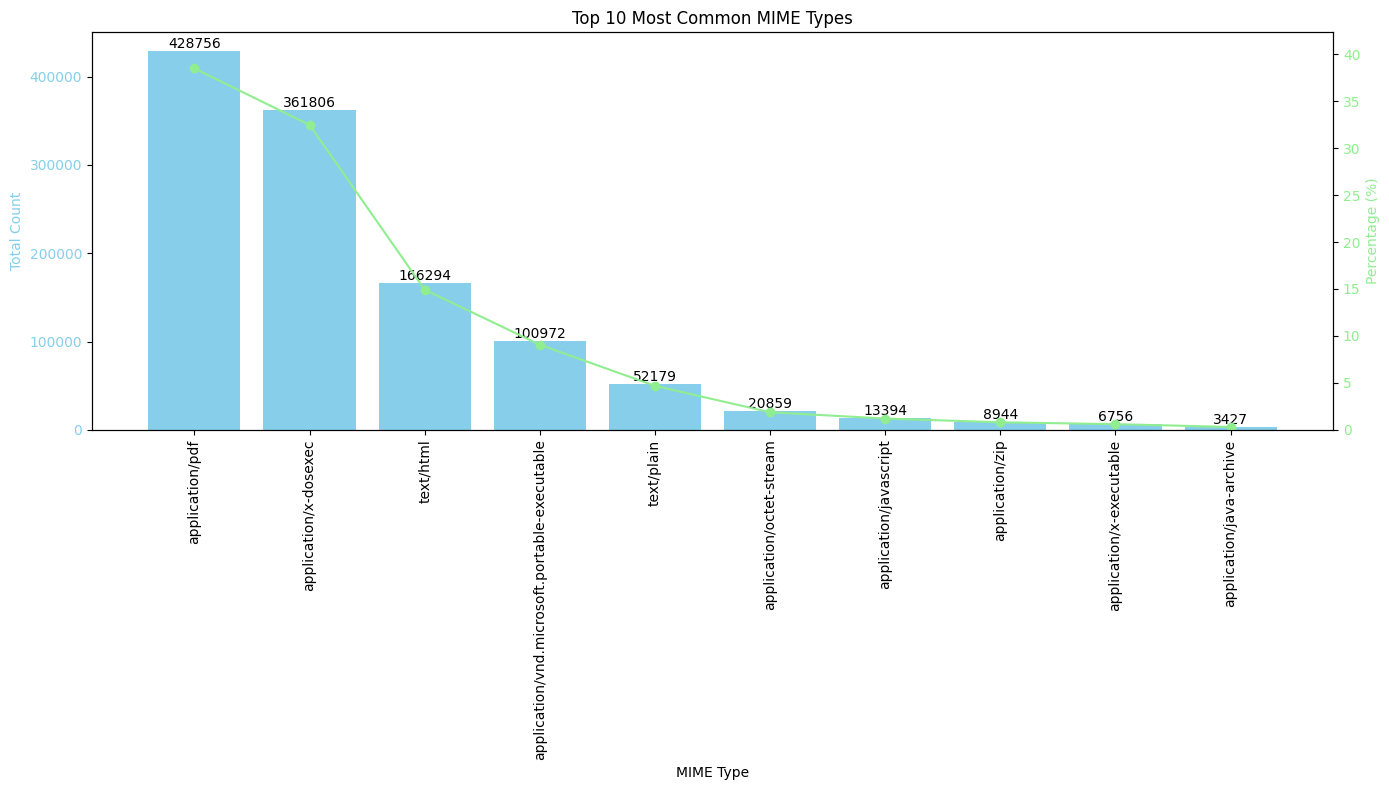

/tmp/ipykernel_111981/465030062.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(bottom_10['MIME Type'], rotation=90)


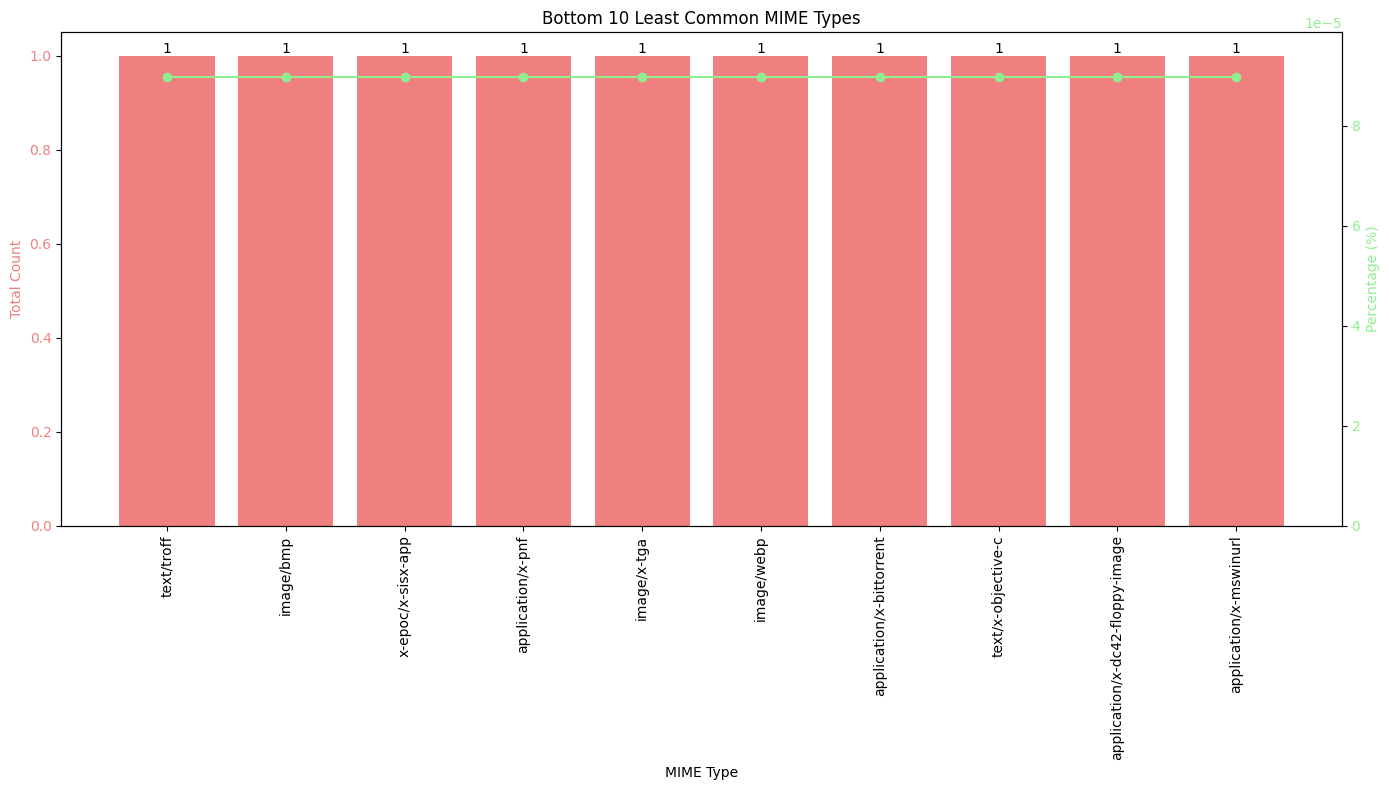

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming mime_totals_df is already defined with 'MIME Type' and 'Total Count'

# Calculate the total number of samples
total_samples = mime_totals_df['Total Count'].sum()

# Calculate the percentage of each MIME type
mime_totals_df['Percentage'] = (mime_totals_df['Total Count'] / 1114112) * 100

# Sort the data by the total count in descending order
mime_totals_df = mime_totals_df.sort_values(by='Total Count', ascending=False)

# Select the top 10 most common and 10 least common MIME types
top_10 = mime_totals_df.head(10)
bottom_10 = mime_totals_df.tail(10)

# Plot the bar chart for the top 10 most common MIME types
fig, ax1 = plt.subplots(figsize=(14, 8))

# Plot count
bars = ax1.bar(top_10['MIME Type'], top_10['Total Count'], color='skyblue', label='Total Count')
ax1.set_title('Top 10 Most Common MIME Types')
ax1.set_xlabel('MIME Type')
ax1.set_ylabel('Total Count', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.set_xticklabels(top_10['MIME Type'], rotation=90)

# Add the count value on top of each bar
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center', fontsize=10)

# Create a second y-axis for percentage
ax2 = ax1.twinx()
ax2.set_ylabel('Percentage (%)', color='lightgreen')
ax2.tick_params(axis='y', labelcolor='lightgreen')

# Plot percentage
ax2.plot(top_10['MIME Type'], top_10['Percentage'], color='lightgreen', marker='o', label='Percentage')
ax2.set_ylim(0, max(top_10['Percentage']) * 1.1)  # Set limits for better visibility

fig.tight_layout()
plt.show()

# Plot the bar chart for the bottom 10 least common MIME types
fig, ax3 = plt.subplots(figsize=(14, 8))

# Plot count
bars_bottom = ax3.bar(bottom_10['MIME Type'], bottom_10['Total Count'], color='lightcoral', label='Total Count')
ax3.set_title('Bottom 10 Least Common MIME Types')
ax3.set_xlabel('MIME Type')
ax3.set_ylabel('Total Count', color='lightcoral')
ax3.tick_params(axis='y', labelcolor='lightcoral')
ax3.set_xticklabels(bottom_10['MIME Type'], rotation=90)

# Add the count value on top of each bar
for bar in bars_bottom:
    yval = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center', fontsize=10)

# Create a second y-axis for percentage
ax4 = ax3.twinx()
ax4.set_ylabel('Percentage (%)', color='lightgreen')
ax4.tick_params(axis='y', labelcolor='lightgreen')

# Plot percentage
ax4.plot(bottom_10['MIME Type'], bottom_10['Percentage'], color='lightgreen', marker='o', label='Percentage')
ax4.set_ylim(0, max(bottom_10['Percentage']) * 1.1)  # Set limits for better visibility

fig.tight_layout()
plt.show()


Counts from all MIME Types

In [14]:
import pandas as pd

# Assuming mime_totals_df is already defined and sorted

# Calculate the total sum of all samples
total_samples = mime_totals_df.copy()
total_samples = total_samples['Total Count'].sum()

# Append a row with the total number of samples
total_row = pd.DataFrame({'MIME Type': ['All Samples'], 'Total Count': [total_samples]})
mime_totals_df_with_total = pd.concat([mime_totals_df, total_row], ignore_index=True)

# Calculate percentages
mime_totals_df_with_total['Percentage'] = mime_totals_df_with_total['Total Count'] / total_samples * 100

# Format the percentage to two decimal places for display
mime_totals_df_with_total['Percentage'] = mime_totals_df_with_total['Percentage'].apply(lambda x: f"{x:.2f}%")

# Print the sorted DataFrame in a nicely formatted table with percentages
print(mime_totals_df_with_total.to_string(index=False))

# Save the updated DataFrame to CSV, including the new total row and percentage column
mime_totals_df_with_total.to_csv('sorted_mime_counts_with_total.csv', index=False)

# Count the number of MIME types that have a count of 1 (excluding the total row)
mime_types_count_1 = mime_totals_df[mime_totals_df['Total Count'] == 1]

# Print the number of MIME types with a count of 1
print(f'Number of MIME types with a count of 1: {len(mime_types_count_1)}')

                                                                MIME Type  Total Count Percentage
                                                          application/pdf       428756     36.35%
                                                    application/x-dosexec       361806     30.67%
                                                                text/html       166294     14.10%
                            application/vnd.microsoft.portable-executable       100972      8.56%
                                                               text/plain        52179      4.42%
                                                 application/octet-stream        20859      1.77%
                                                   application/javascript        13394      1.14%
                                                          application/zip         8944      0.76%
                                                 application/x-executable         6756      0.57%
                    

In [15]:
# Preparing data for plotting top two MIME types per CSV file
virusshare_dates = {
    "mime_counts00469.csv": "2023-05-08",
    "mime_counts00470.csv": "2023-05-18",
    "mime_counts00471.csv": "2023-05-23",
    "mime_counts00472.csv": "2023-06-13",
    "mime_counts00473.csv": "2023-06-19",
    "mime_counts00474.csv": "2023-06-25",
    "mime_counts00475.csv": "2023-07-07",
    "mime_counts00476.csv": "2023-07-14",
    "mime_counts00477.csv": "2023-08-07",
    "mime_counts00478.csv": "2023-08-13",
    "mime_counts00479.csv": "2023-08-20",
    "mime_counts00480.csv": "2023-09-09",
    "mime_counts00481.csv": "2023-09-22",
    "mime_counts00482.csv": "2023-10-21",
    "mime_counts00483.csv": "2023-11-04",
    "mime_counts00484.csv": "2023-11-10",
    "mime_counts00485.csv": "2024-02-07",
    "mime_counts00486.csv": "2024-02-14",
}

# Creating a mapping dictionary for renaming
mime_to_name_mapping = {
    'application/pdf': 'PDF Document',
    'application/x-dosexec': 'Windows Executable',
    'text/html': 'HTML Document',
    'application/vnd.microsoft.portable-executable': 'Portable Executable (Windows)',
    'text/plain': 'Plain Text',
    'application/octet-stream': 'Binary File',
    'application/javascript': 'JavaScript File',
    'application/zip': 'ZIP Archive',
    'application/x-executable': 'Executable File (General)',
    'application/vnd.android.package-archive': 'Android APK',
    'application/x-msdos-batch': 'Batch Script',
    'text/xml': 'XML Document',
    'text/x-php': 'PHP Script',
    'application/x-ms-shortcut': 'Windows Shortcut',
    'application/x-rar': 'RAR Archive'
}


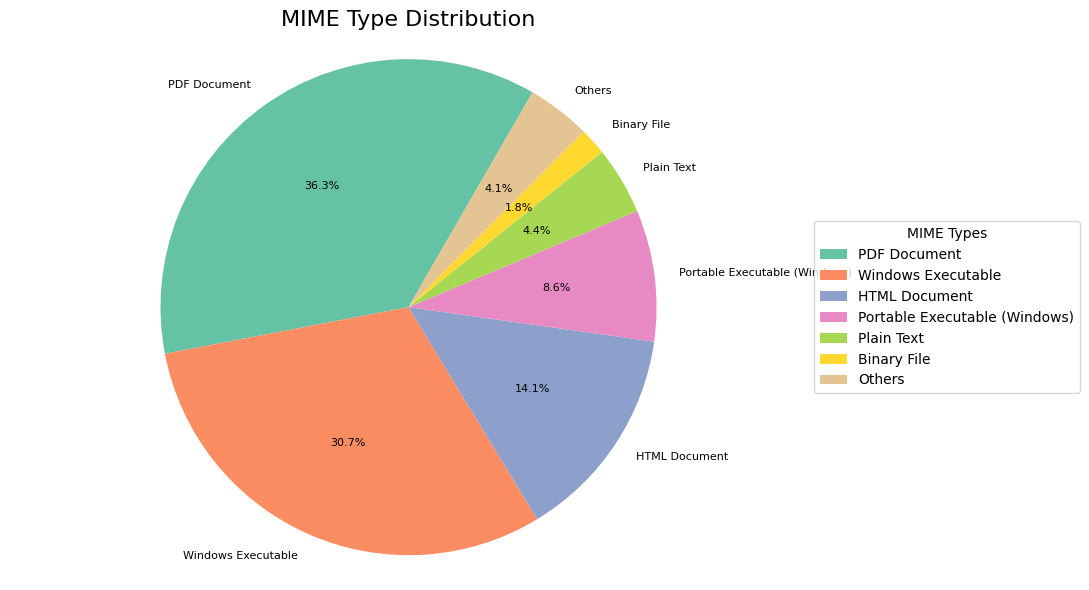

In [30]:
# Calculate percentages
mime_totals_df['Percentage'] = (mime_totals_df['Total Count'] / total_samples) * 100

# Create 'Others' category for MIME types with less than 1%
df_others = mime_totals_df[mime_totals_df['Percentage'] < 1.5].sum()
df_others['MIME Type'] = 'Others'
df_others['Percentage'] = df_others['Percentage'].round(2)

# Filter out MIME types less than 1% and add 'Others'
df_major = mime_totals_df[mime_totals_df['Percentage'] >= 1.5]
df_chart = pd.concat([df_major, df_others.to_frame().T], ignore_index=True)

# Preparing for the pie chart
labels = df_chart['MIME Type']
labels = labels.map(mime_to_name_mapping)
labels = labels.fillna('Others')
sizes = df_chart['Percentage']

# Colors for the pie chart
colors = sns.color_palette("Set2", len(labels))  # Using Set2 palette from seaborn

# Create a mapping from MIME type (keys of the dictionary) to colors
mime_type_to_color = {mime: colors[i] for i, mime in enumerate(labels)}

# Create pie chart
fig, ax = plt.subplots(figsize=(11, 6))
wedges, texts, autotexts = ax.pie(sizes, labels=labels, colors=colors, 
                                  autopct=lambda p: '{:.1f}%'.format(p),
                                    startangle=60, 
                                  textprops={'fontsize': 8})



# Adjust layout
plt.title("MIME Type Distribution", fontsize=16)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Adjusting legend for better readability
ax.legend(wedges, labels,
          title="MIME Types",
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1))

plt.tight_layout()
plt.show()

# Optionally, save the figure
# plt.savefig('mime_type_distribution_pie_chart.png', bbox_inches='tight')

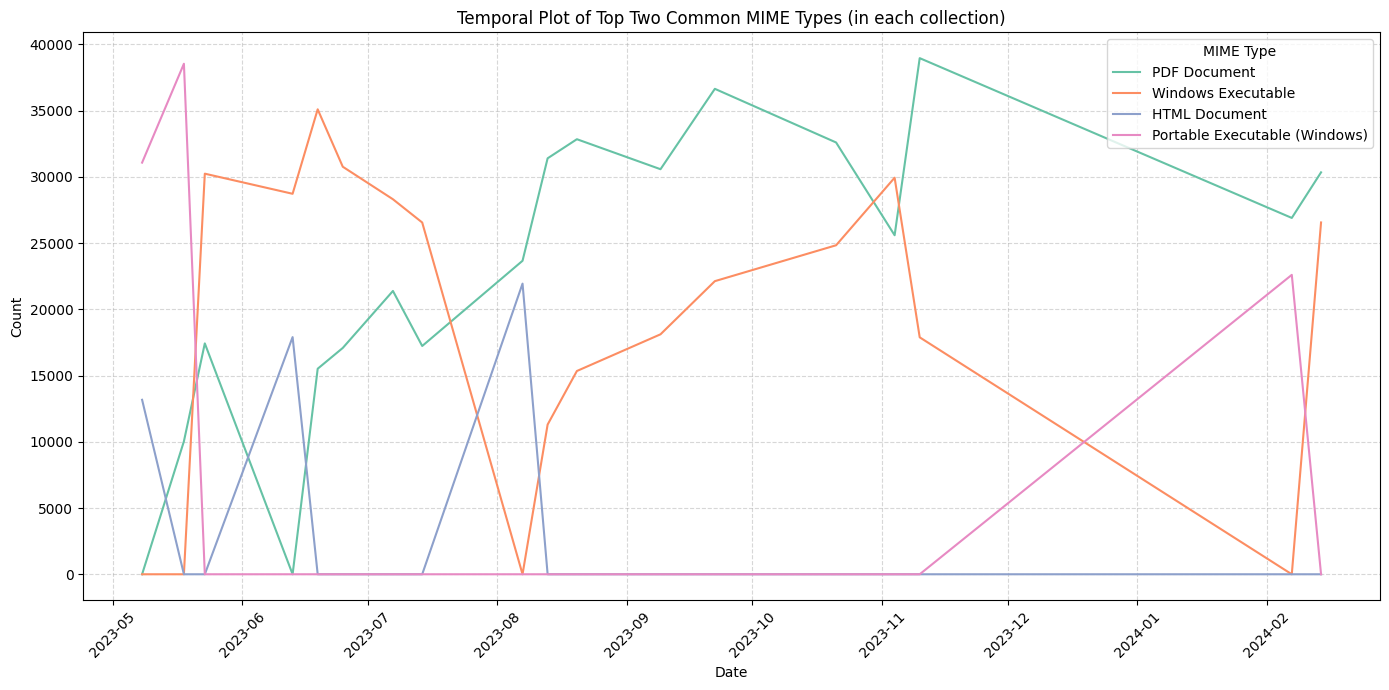

In [31]:
# Plotting
temporal_data2 = {
    'PDF Document': [],
    'Windows Executable': [],
    'HTML Document': [],
    'Portable Executable (Windows)': [],
}

# Populating the temporal data dictionary
for file, mime_list in temporal_data_16.items():
    date = pd.to_datetime(virusshare_dates[file])
    updated_types = set()  # To keep track of which types were updated

    for mime_type, count in mime_list[:2]:  # Only take the top two types
        if mime_type in mime_to_name_mapping:
            conventional_name = mime_to_name_mapping[mime_type]
            temporal_data2[conventional_name].append((file, count))
            updated_types.add(conventional_name)
  
    for key in temporal_data2.keys():
            if key not in updated_types:
                temporal_data2[key].append((file, 0))
        

# Colors for the pie chart
colors = sns.color_palette("Set2", len(temporal_data2))  # Using Set2 palette from seaborn

# Create a mapping from MIME type (keys of the dictionary) to colors
mime_type_to_color = {mime: colors[i] for i, mime in enumerate(temporal_data2)}


plt.figure(figsize=(14, 7))
for mime_type, data in temporal_data2.items():
    # Replace filenames with dates and sort data by date
    data = [(pd.to_datetime(virusshare_dates.get(filename)), count) for filename, count in data]
    data = sorted(data, key=lambda x: x[0])

    # Extract dates and counts for plotting
    dates, counts = zip(*data) if data else ([], [])

    # Plot the temporal trend
    if dates:  # Ensure there is data to plot
        plt.plot(dates, counts, label=mime_type,  color=mime_type_to_color[mime_type])

plt.title('Temporal Plot of Top Two Common MIME Types (in each collection)')
plt.xlabel('Date')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='MIME Type')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


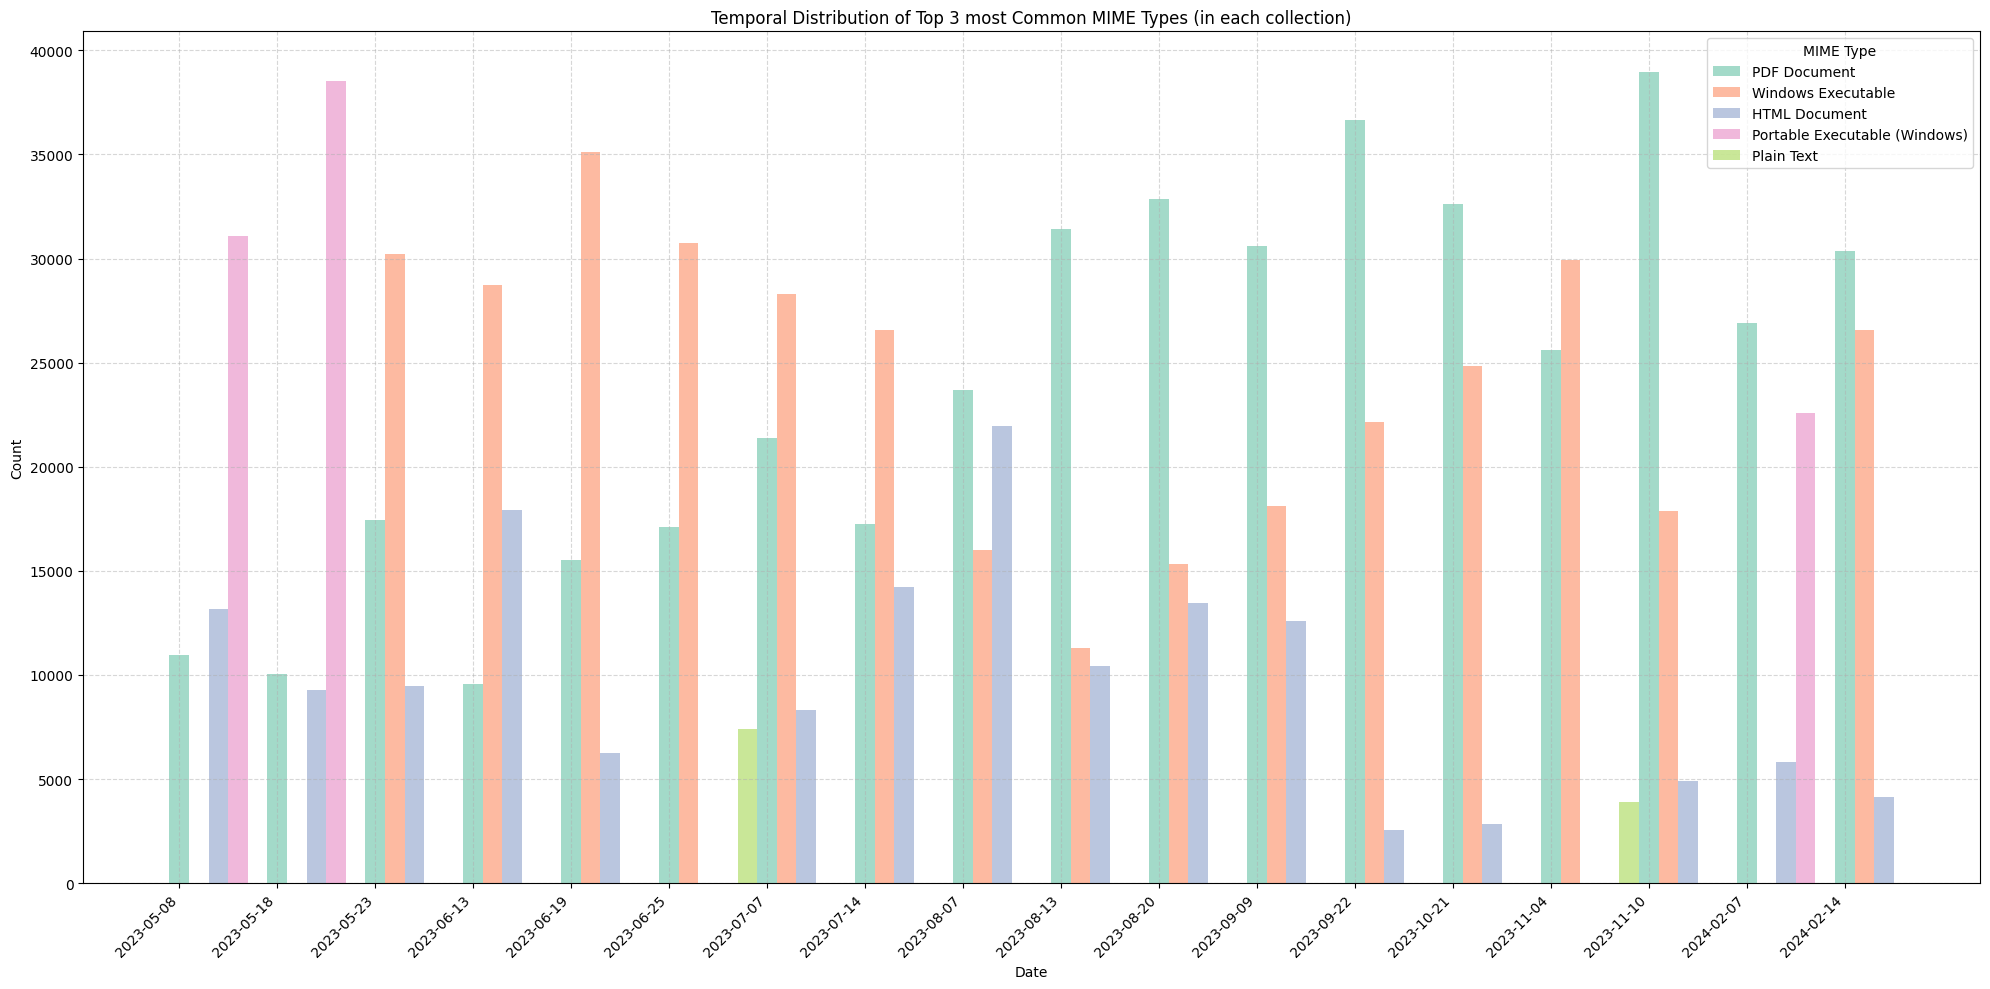

In [29]:
import matplotlib.pyplot as plt
import pandas as pd

temporal_data2 = {
    'PDF Document': [],
    'Windows Executable': [],
    'HTML Document': [],
    'Portable Executable (Windows)': [],
    'Plain Text': [],
    'Binary File': [],
    'JavaScript File': [],
    'ZIP Archive': [],
    'Executable File (General)': [],
    'Android APK': [],
    'Batch Script': [],
    'XML Document': [],
    'PHP Script': [],
    'Windows Shortcut': [],
    'RAR Archive': []
}

# Populating the temporal data dictionary
for file, mime_list in temporal_data_16.items():
    date = pd.to_datetime(virusshare_dates[file])
    for mime_type, count in mime_list[:3]:  # Only take the top two types
        if mime_type in mime_to_name_mapping:
            conventional_name = mime_to_name_mapping[mime_type]
            temporal_data2[conventional_name].append((file, count))


colors = sns.color_palette("Set2", len(temporal_data2))  # Using Set2 palette from seaborn

# Create a mapping from MIME type (keys of the dictionary) to colors
mime_type_to_color = {mime: colors[i] for i, mime in enumerate(temporal_data2.keys())}

# Prepare figure for the bar graph
plt.figure(figsize=(20, 10))

# Define the width of the bars
bar_width = 0.2

# Loop through each MIME type and create a bar plot
all_dates = set()
for mime_type, data in temporal_data2.items():
    # Replace filenames with dates and sort data by date
    data = [(pd.to_datetime(virusshare_dates.get(filename)), count) for filename, count in data]
    data = sorted(data, key=lambda x: x[0])

    # Extract dates and counts for plotting
    if data:
        dates, counts = zip(*data)

        # Add dates to a set to get unique dates
        all_dates.update(dates)

# Sort all the unique dates
all_dates = sorted(all_dates)

# Create a mapping of dates to indices for the x-axis
date_to_index = {date: idx for idx, date in enumerate(all_dates)}

# Plot bars for each MIME type
for idx, (mime_type, data) in enumerate(temporal_data2.items()):
    # Replace filenames with dates and sort data by date
    data = [(pd.to_datetime(virusshare_dates.get(filename)), count) for filename, count in data]
    data = sorted(data, key=lambda x: x[0])

    # Extract dates and counts for plotting
    if data:
        dates, counts = zip(*data)

        # Convert dates to their corresponding indices on the x-axis
        date_indices = [date_to_index[date] for date in dates]

        # Plot the bars for the current MIME type with an offset
        plt.bar([x + idx * bar_width for x in date_indices], counts, width=bar_width, label=mime_type, alpha=0.6,color=mime_type_to_color[mime_type])

# Adjust x-ticks to match the dates
plt.xticks(range(len(all_dates)), [date.strftime('%Y-%m-%d') for date in all_dates], rotation=45, ha='right')

# Set the plot title and labels
plt.title('Temporal Distribution of Top 3 most Common MIME Types (in each collection)')
plt.xlabel('Date')
plt.ylabel('Count')

# Display a legend to identify each MIME type
plt.legend(title='MIME Type')

# Add a grid for better readability
plt.grid(True, linestyle='--', alpha=0.5)

# Adjust layout to avoid label cutoff
plt.tight_layout()

# Show the bar graph
plt.show()


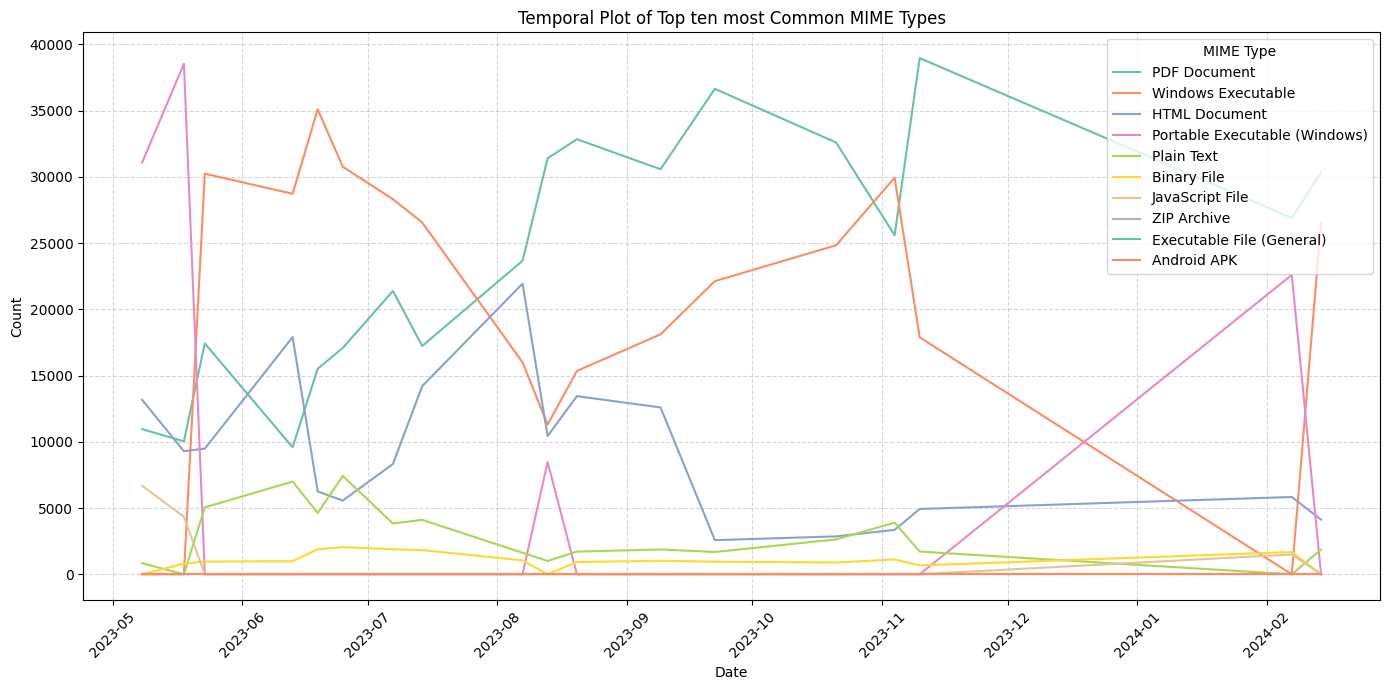

In [19]:
temporal_data16 = {
    'PDF Document': [],
    'Windows Executable': [],
    'HTML Document': [],
    'Portable Executable (Windows)': [],
    'Plain Text': [],
    'Binary File': [],
    'JavaScript File': [],
    'ZIP Archive': [],
    'Executable File (General)': [],
    'Android APK': [],
}

mime_to_name_mapping_trimmed = {
    'application/pdf': 'PDF Document',
    'application/x-dosexec': 'Windows Executable',
    'text/html': 'HTML Document',
    'application/vnd.microsoft.portable-executable': 'Portable Executable (Windows)',
    'text/plain': 'Plain Text',
    'application/octet-stream': 'Binary File',
    'application/javascript': 'JavaScript File',
    'application/zip': 'ZIP Archive',
    'application/x-executable': 'Executable File (General)',
    'application/vnd.android.package-archive': 'Android APK',
}


# Populating the temporal data dictionary
for file, mime_list in temporal_data_16.items():
    date = pd.to_datetime(virusshare_dates[file])
    updated_types = set()  # To keep track of which types were updated

    for mime_type, count in mime_list[:16]:  # Only take the top two types
    
             
        if mime_type in mime_to_name_mapping_trimmed:
            conventional_name = mime_to_name_mapping[mime_type]
            temporal_data16[conventional_name].append((file, count))
            updated_types.add(conventional_name)
  
    for key in temporal_data16.keys():
            if key not in updated_types:
                temporal_data16[key].append((file, 0))

                
colors = sns.color_palette("Set2", len(mime_to_name_mapping))  # Using Set2 palette from seaborn

# Create a mapping from MIME type to color
mime_type_to_color = {mime: colors[i] for i, mime in enumerate(mime_to_name_mapping.values())}

# Plotting
plt.figure(figsize=(14, 7))

for mime_type, data in temporal_data16.items():
    # Replace filenames with dates and sort data by date
    data = [(pd.to_datetime(virusshare_dates.get(filename)), count) for filename, count in data]
    data = sorted(data, key=lambda x: x[0])

    # Extract dates and counts for plotting
    dates, counts = zip(*data) if data else ([], [])

    # Plot the temporal trend using the fixed colors from mime_type_to_color
    if dates:  # Ensure there is data to plot
        plt.plot(dates, counts, label=mime_type, color=mime_type_to_color.get(mime_type))

plt.title('Temporal Plot of Top ten most Common MIME Types')
plt.xlabel('Date')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='MIME Type')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


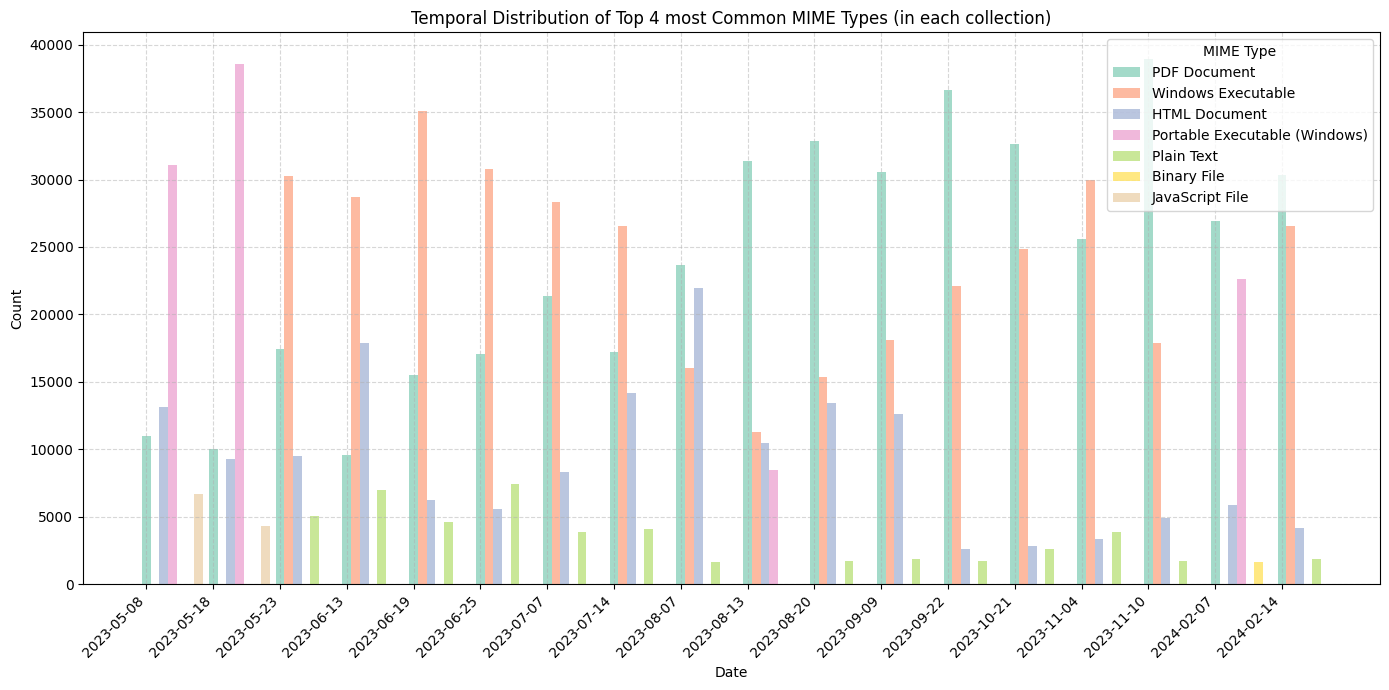

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

temporal_data4 = {
    'PDF Document': [],
    'Windows Executable': [],
    'HTML Document': [],
    'Portable Executable (Windows)': [],
    'Plain Text': [],
    'Binary File': [],
    'JavaScript File': [],
    'ZIP Archive': [],
    'Executable File (General)': [],
    'Android APK': [],
    'Batch Script': [],
    'XML Document': [],
    'PHP Script': [],
    'Windows Shortcut': [],
    'RAR Archive': []
}



# Populating the temporal data dictionary
for file, mime_list in temporal_data_16.items():
    date = pd.to_datetime(virusshare_dates[file])
    for mime_type, count in mime_list[:4]:  # Only take the top 4 types
        if mime_type in mime_to_name_mapping:
            conventional_name = mime_to_name_mapping[mime_type]
            temporal_data4[conventional_name].append((file, count))

# Prepare figure for the bar graph
plt.figure(figsize=(14, 7))

# Define the width of the bars
bar_width = 0.13  # Slightly smaller bar width to fit 4 bars in each group

colors = sns.color_palette("Set2", len(temporal_data4))  # Using Set2 palette from seaborn

# Create a mapping from MIME type (keys of the dictionary) to colors
mime_type_to_color = {mime: colors[i] for i, mime in enumerate(temporal_data4.keys())}

# Get all unique dates
all_dates = set()
for mime_type, data in temporal_data4.items():
    # Replace filenames with dates and sort data by date
    data = [(pd.to_datetime(virusshare_dates.get(filename)), count) for filename, count in data]
    data = sorted(data, key=lambda x: x[0])

    # Extract dates to get the unique set of dates
    if data:
        dates, _ = zip(*data)
        all_dates.update(dates)

# Sort all the unique dates
all_dates = sorted(all_dates)

# Create a mapping of dates to indices for the x-axis
date_to_index = {date: idx for idx, date in enumerate(all_dates)}

# Plot bars for each MIME type
for idx, (mime_type, data) in enumerate(temporal_data4.items()):
    # Replace filenames with dates and sort data by date
    data = [(pd.to_datetime(virusshare_dates.get(filename)), count) for filename, count in data]
    data = sorted(data, key=lambda x: x[0])

    # Extract dates and counts for plotting
    if data:
        dates, counts = zip(*data)

        # Convert dates to their corresponding indices on the x-axis
        date_indices = [date_to_index[date] for date in dates]

        # Plot the bars for the current MIME type with an offset
        plt.bar([x + idx * bar_width for x in date_indices], counts, width=bar_width, label=mime_type, alpha=0.6, color=mime_type_to_color[mime_type])

# Adjust x-ticks to match the dates
plt.xticks(range(len(all_dates)), [date.strftime('%Y-%m-%d') for date in all_dates], rotation=45, ha='right')

# Set the plot title and labels
plt.title('Temporal Distribution of Top 4 most Common MIME Types (in each collection)')
plt.xlabel('Date')
plt.ylabel('Count')

# Display a legend to identify each MIME type
plt.legend(title='MIME Type')

# Add a grid for better readability
plt.grid(True, linestyle='--', alpha=0.5)

# Adjust layout to avoid label cutoff
plt.tight_layout()

# Show the bar graph
plt.show()


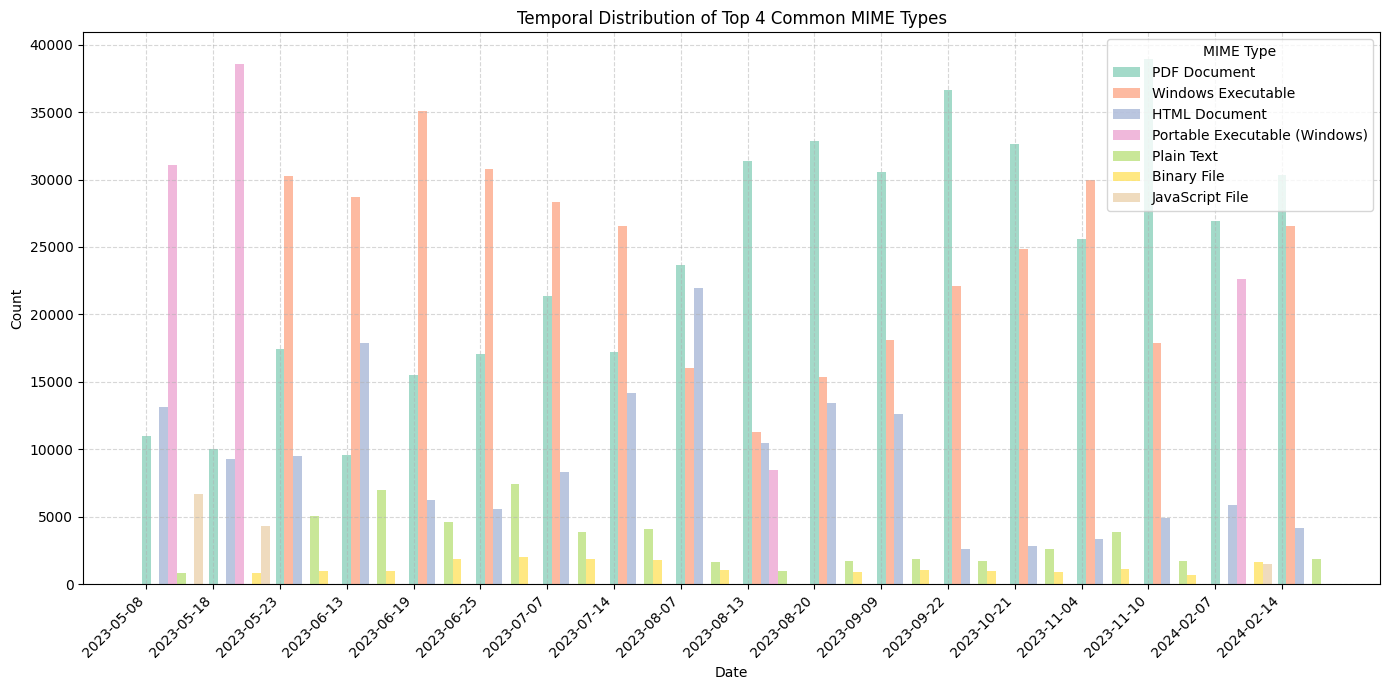

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

temporal_data16 = {
    'PDF Document': [],
    'Windows Executable': [],
    'HTML Document': [],
    'Portable Executable (Windows)': [],
    'Plain Text': [],
    'Binary File': [],
    'JavaScript File': [],
    'ZIP Archive': [],
    'Executable File (General)': [],
    'Android APK': [],
    'Batch Script': [],
    'XML Document': [],
    'PHP Script': [],
    'Windows Shortcut': [],
    'RAR Archive': []
}

# Populating the temporal data dictionary
for file, mime_list in temporal_data_16.items():
    date = pd.to_datetime(virusshare_dates[file])
    for mime_type, count in mime_list[:16]:  # Only take the top 4 types
        if mime_type in mime_to_name_mapping:
            conventional_name = mime_to_name_mapping[mime_type]
            temporal_data16[conventional_name].append((file, count))

# Prepare figure for the bar graph
plt.figure(figsize=(14, 7))

# Define the width of the bars
bar_width = 0.13  # Slightly smaller bar width to fit 4 bars in each group

colors = sns.color_palette("Set2", len(temporal_data16))  # Using Set2 palette from seaborn

# Create a mapping from MIME type (keys of the dictionary) to colors
mime_type_to_color = {mime: colors[i] for i, mime in enumerate(temporal_data16.keys())}


# Get all unique dates
all_dates = set()
for mime_type, data in temporal_data16.items():
    # Replace filenames with dates and sort data by date
    data = [(pd.to_datetime(virusshare_dates.get(filename)), count) for filename, count in data]
    data = sorted(data, key=lambda x: x[0])

    # Extract dates to get the unique set of dates
    if data:
        dates, _ = zip(*data)
        all_dates.update(dates)

# Sort all the unique dates
all_dates = sorted(all_dates)

# Create a mapping of dates to indices for the x-axis
date_to_index = {date: idx for idx, date in enumerate(all_dates)}

# Plot bars for each MIME type
for idx, (mime_type, data) in enumerate(temporal_data16.items()):
    # Replace filenames with dates and sort data by date
    data = [(pd.to_datetime(virusshare_dates.get(filename)), count) for filename, count in data]
    data = sorted(data, key=lambda x: x[0])

    # Extract dates and counts for plotting
    if data:
        dates, counts = zip(*data)

        # Convert dates to their corresponding indices on the x-axis
        date_indices = [date_to_index[date] for date in dates]

        # Plot the bars for the current MIME type with an offset
        plt.bar([x + idx * bar_width for x in date_indices], counts, width=bar_width, label=mime_type, alpha=0.6,  color=mime_type_to_color[mime_type])

# Adjust x-ticks to match the dates
plt.xticks(range(len(all_dates)), [date.strftime('%Y-%m-%d') for date in all_dates], rotation=45, ha='right')

# Set the plot title and labels
plt.title('Temporal Distribution of Top 4 Common MIME Types')
plt.xlabel('Date')
plt.ylabel('Count')

# Display a legend to identify each MIME type
plt.legend(title='MIME Type')

# Add a grid for better readability
plt.grid(True, linestyle='--', alpha=0.5)

# Adjust layout to avoid label cutoff
plt.tight_layout()

# Show the bar graph
plt.show()


Columns in mime_counts00469.csv: ['MIME_type', 'Count', 'Virus_Share_Package']
Columns in mime_counts00470.csv: ['MIME_type', 'Count', 'Virus_Share_Package']
Columns in mime_counts00471.csv: ['MIME_type', 'Count', 'Virus_Share_Package']
Columns in mime_counts00472.csv: ['MIME_type', 'Count', 'Virus_Share_Package']
Columns in mime_counts00473.csv: ['MIME_type', 'Count', 'Virus_Share_Package']
Columns in mime_counts00474.csv: ['MIME_type', 'Count', 'Virus_Share_Package']
Columns in mime_counts00475.csv: ['MIME_type', 'Count', 'Virus_Share_Package']
Columns in mime_counts00476.csv: ['MIME_type', 'Count', 'Virus_Share_Package']
Columns in mime_counts00477.csv: ['MIME_type', 'Count', 'Virus_Share_Package']
Columns in mime_counts00478.csv: ['MIME_type', 'Count', 'Virus_Share_Package']
Columns in mime_counts00479.csv: ['MIME_type', 'Count', 'Virus_Share_Package']
Columns in mime_counts00480.csv: ['MIME_type', 'Count', 'Virus_Share_Package']
Columns in mime_counts00481.csv: ['MIME_type', 'Coun

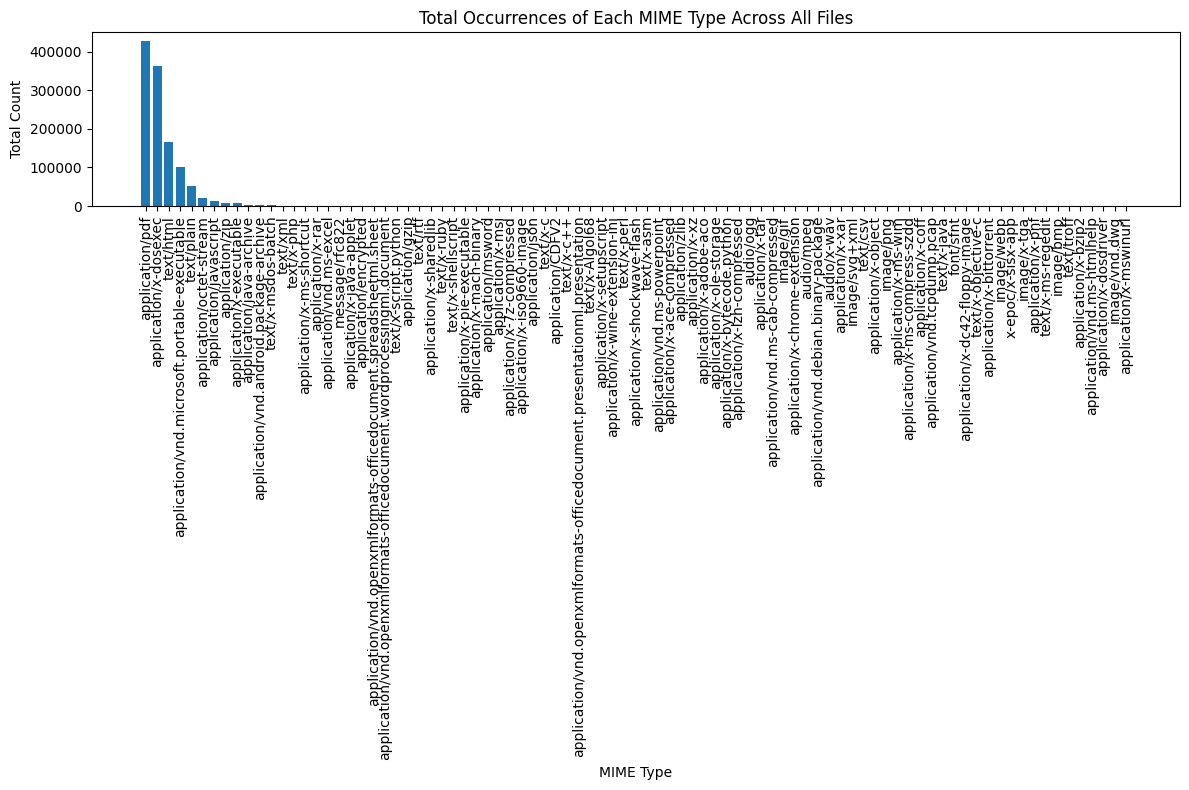

In [22]:
# Directory containing the mime_counts004xx.csv files
directory = './TypeCounts/'

# Dictionary to store the total count of each MIME type across all files
mime_type_totals = {}

# Function to read a CSV file and return a dataframe
def read_mime_counts(file_path):
    return pd.read_csv(file_path)

# Iterate over all files in the directory
for filename in os.listdir(directory):
    if filename.startswith('mime_counts') and filename.endswith('.csv'):
        file_path = os.path.join(directory, filename)
        df = read_mime_counts(file_path)

        # Check column names and print them to understand the format
        print(f"Columns in {filename}: {df.columns.tolist()}")

        # Adjust column names based on the actual column structure
        # Assuming the columns are 'Tipo MIME,Count,Arquivo' in a single string
        # Split the string into separate columns if needed
        if 'Tipo MIME,Count,Arquivo' in df.columns:
            df[['MIME_type', 'Count', 'Arquivo']] = df['Tipo MIME,Count,Arquivo'].str.split(',', expand=True)

        # Convert the 'Count' column to integer
        df['Count'] = df['Count'].astype(int)

        # Accumulate counts for each MIME type
        for index, row in df.iterrows():
            mime_type = row['MIME_type']
            count = row['Count']
            if mime_type not in mime_type_totals:
                mime_type_totals[mime_type] = 0
            mime_type_totals[mime_type] += count

# Convert the accumulated data to a DataFrame for plotting
mime_totals_df = pd.DataFrame(list(mime_type_totals.items()), columns=['MIME Type', 'Total Count'])

# Sort the data by the total count in descending order
mime_totals_df = mime_totals_df.sort_values(by='Total Count', ascending=False)

# Plot the bar chart showing the total occurrences of each MIME type
plt.figure(figsize=(12, 8))
plt.bar(mime_totals_df['MIME Type'], mime_totals_df['Total Count'])
plt.title('Total Occurrences of Each MIME Type Across All Files')
plt.xlabel('MIME Type')
plt.ylabel('Total Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


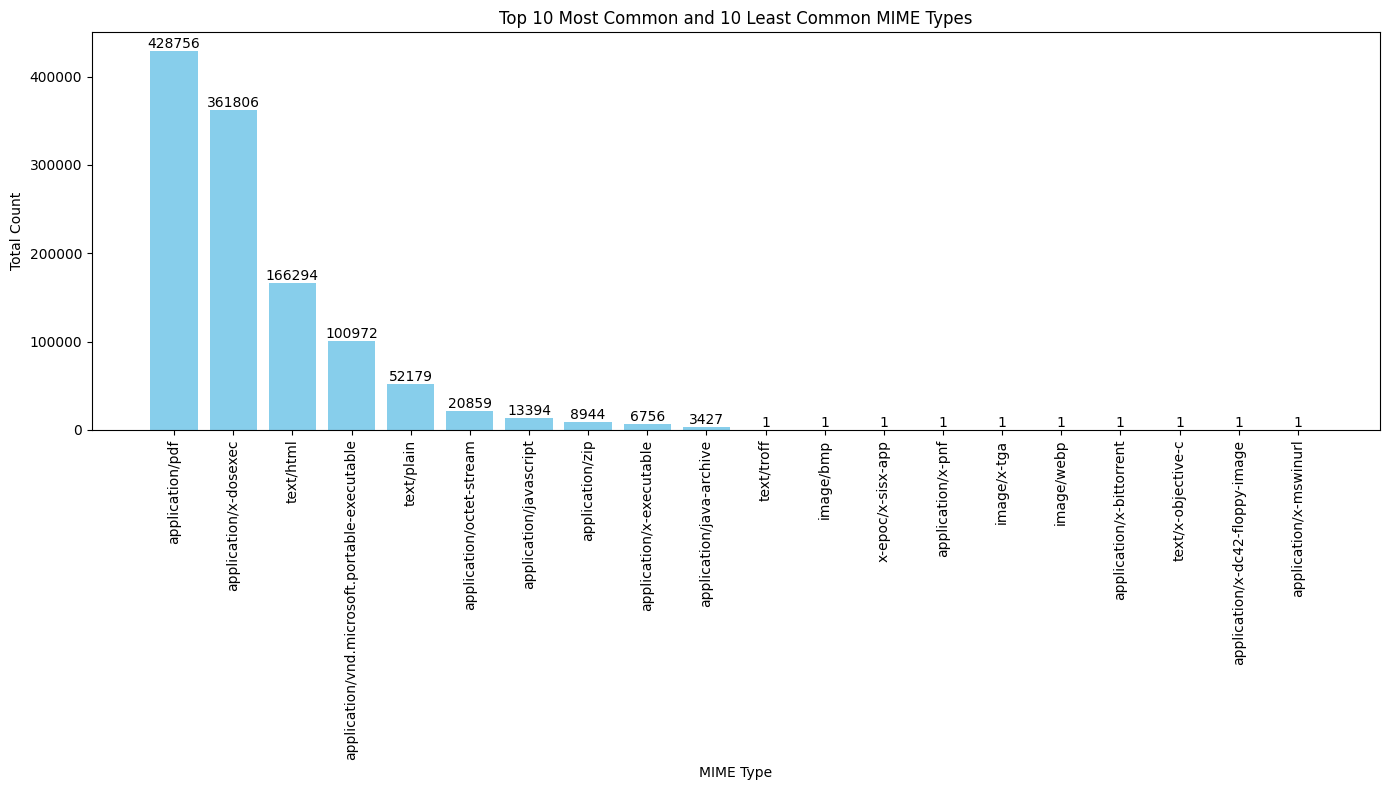

In [23]:
import matplotlib.pyplot as plt

# Sort the data by the total count in descending order
mime_totals_df = mime_totals_df.sort_values(by='Total Count', ascending=False)

# Select the top 10 most common and 10 least common MIME types
top_10 = mime_totals_df.head(10)
bottom_10 = mime_totals_df.tail(10)

# Combine top 10 and bottom 10 into a single DataFrame
combined_df = pd.concat([top_10, bottom_10])

# Plot the bar chart showing the total occurrences for the selected MIME types
plt.figure(figsize=(14, 8))
bars = plt.bar(combined_df['MIME Type'], combined_df['Total Count'], color='skyblue')
plt.title('Top 10 Most Common and 10 Least Common MIME Types')
plt.xlabel('MIME Type')
plt.ylabel('Total Count')
plt.xticks(rotation=90)

# Add the count value on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


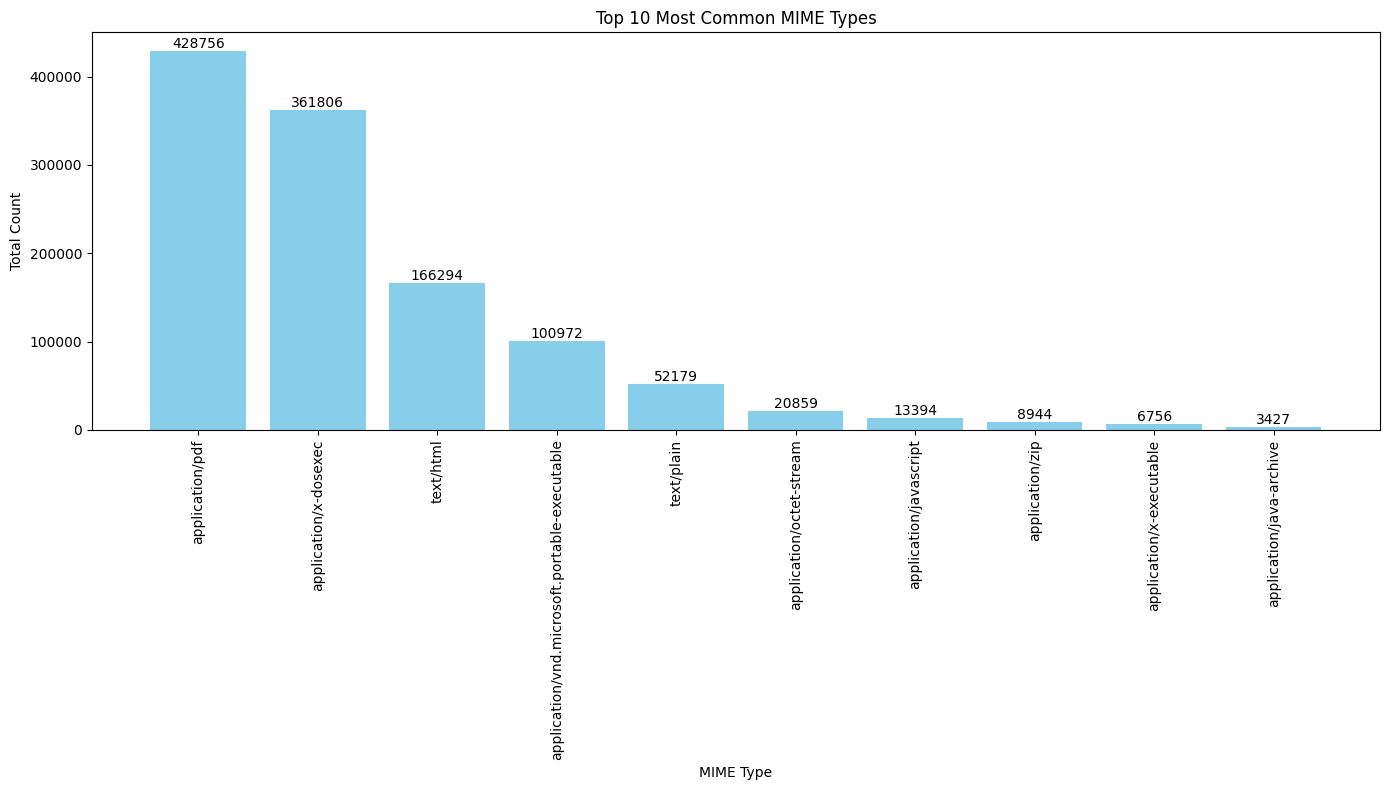

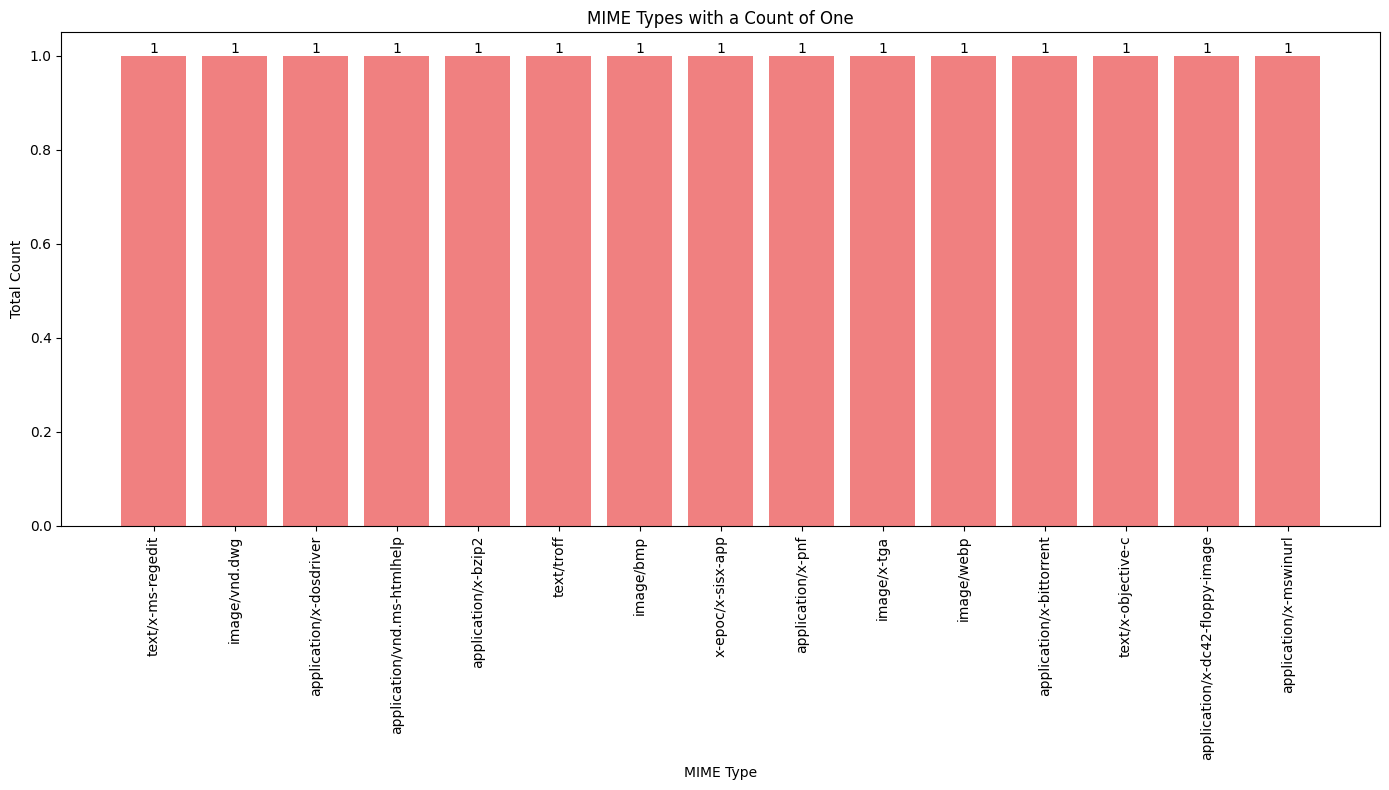

In [24]:
# Filter the data to select MIME types that have a total count of one
count_one_df = mime_totals_df[mime_totals_df['Total Count'] == 1]

# Plot the bar chart for the top 10 most common MIME types
plt.figure(figsize=(14, 8))
bars = plt.bar(top_10['MIME Type'], top_10['Total Count'], color='skyblue')
plt.title('Top 10 Most Common MIME Types')
plt.xlabel('MIME Type')
plt.ylabel('Total Count')
plt.xticks(rotation=90)

# Add the count value on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Plot the bar chart for MIME types that have a count of one
plt.figure(figsize=(14, 8))
bars = plt.bar(count_one_df['MIME Type'], count_one_df['Total Count'], color='lightcoral')
plt.title('MIME Types with a Count of One')
plt.xlabel('MIME Type')
plt.ylabel('Total Count')
plt.xticks(rotation=90)

# Add the count value on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


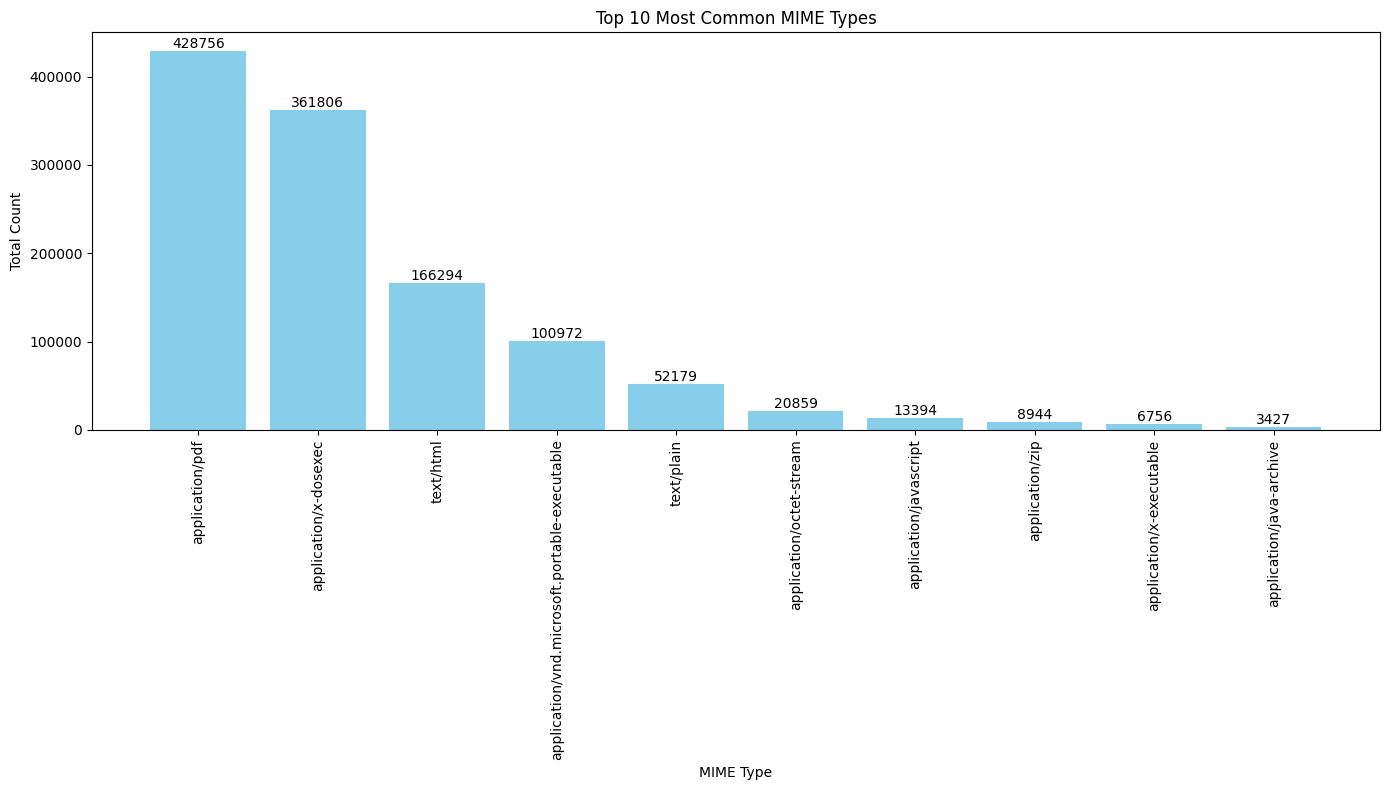

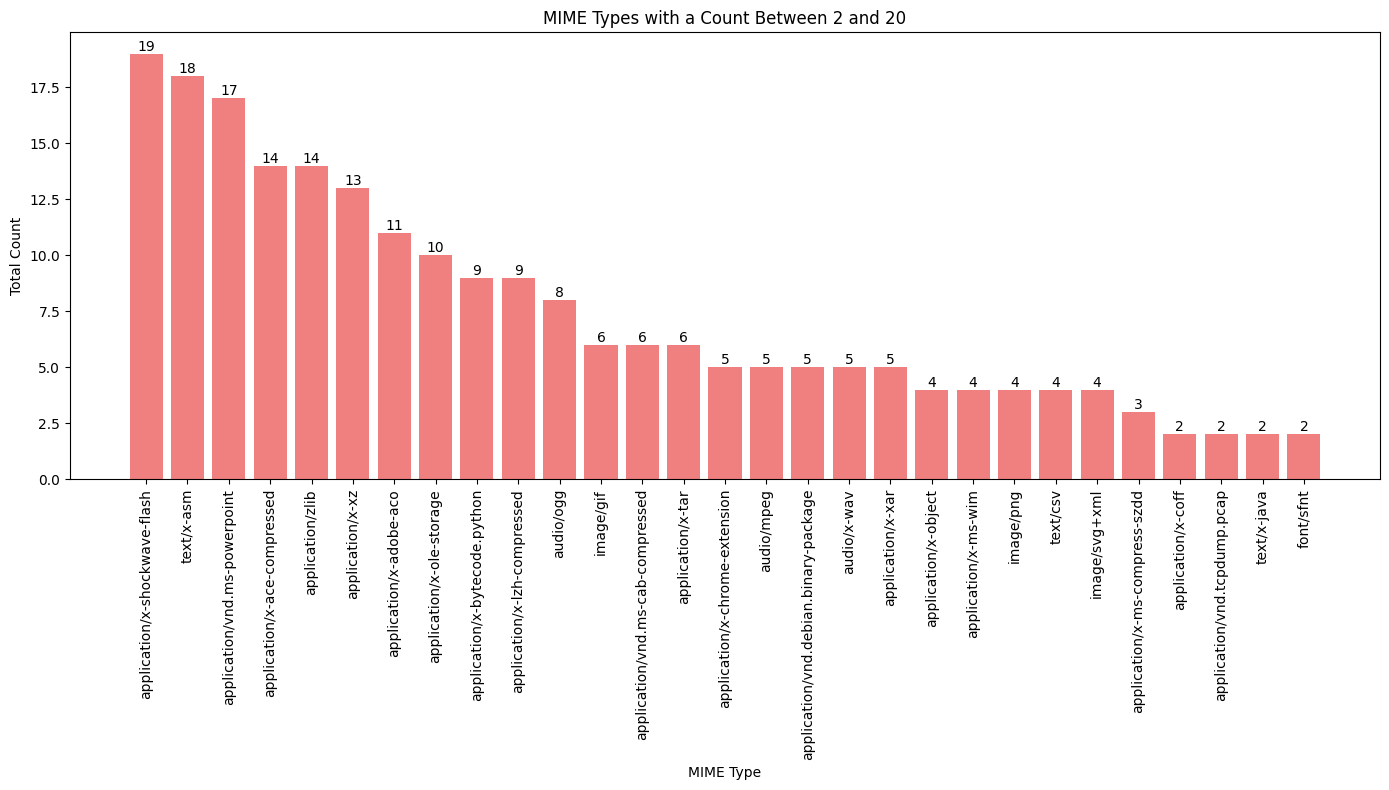

In [25]:
# Filter the data to select MIME types that have a total count between 2 and 20
count_between_2_and_20_df = mime_totals_df[(mime_totals_df['Total Count'] >= 2) & (mime_totals_df['Total Count'] <= 20)]

# Plot the bar chart for the top 10 most common MIME types
plt.figure(figsize=(14, 8))
bars = plt.bar(top_10['MIME Type'], top_10['Total Count'], color='skyblue')
plt.title('Top 10 Most Common MIME Types')
plt.xlabel('MIME Type')
plt.ylabel('Total Count')
plt.xticks(rotation=90)

# Add the count value on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Plot the bar chart for MIME types with a count between 2 and 20
plt.figure(figsize=(14, 8))
bars = plt.bar(count_between_2_and_20_df['MIME Type'], count_between_2_and_20_df['Total Count'], color='lightcoral')
plt.title('MIME Types with a Count Between 2 and 20')
plt.xlabel('MIME Type')
plt.ylabel('Total Count')
plt.xticks(rotation=90)

# Add the count value on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

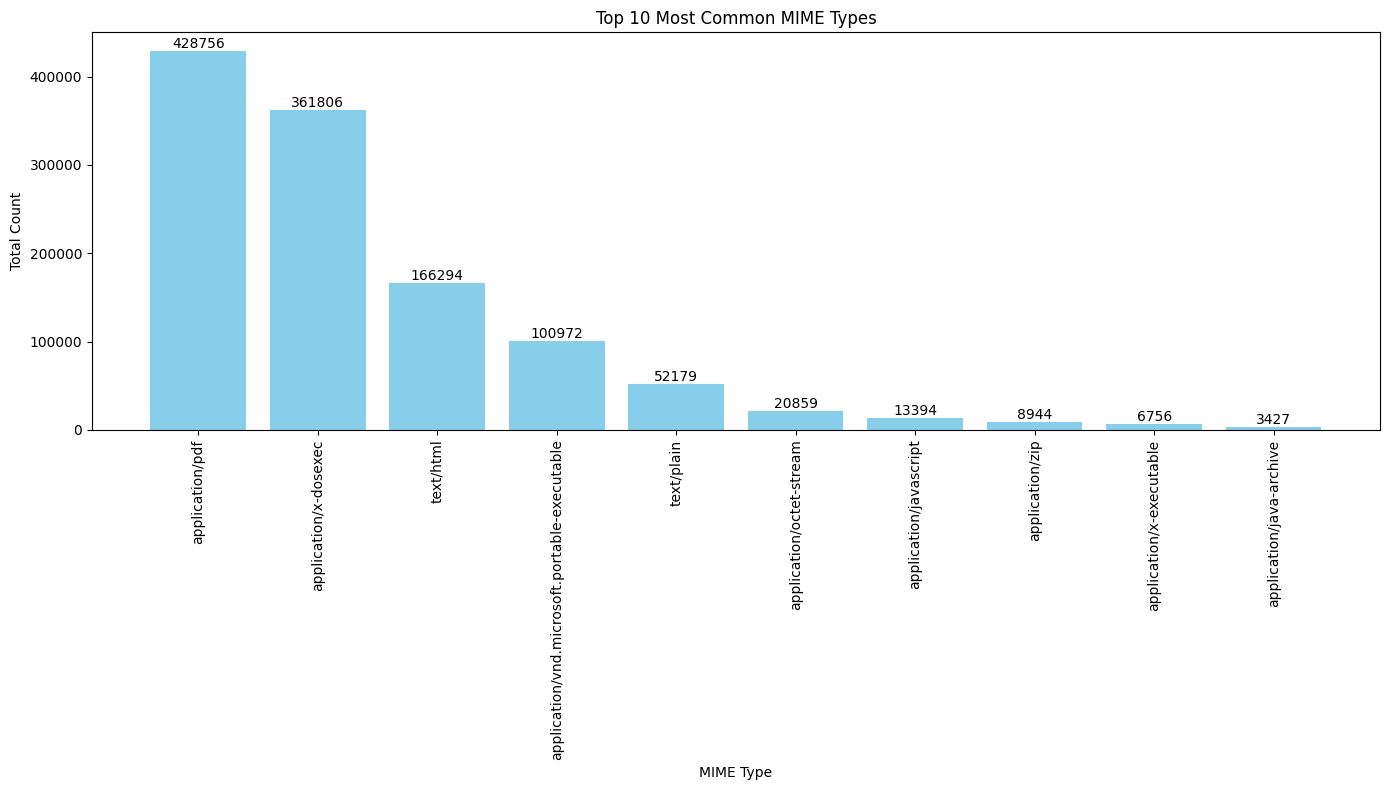

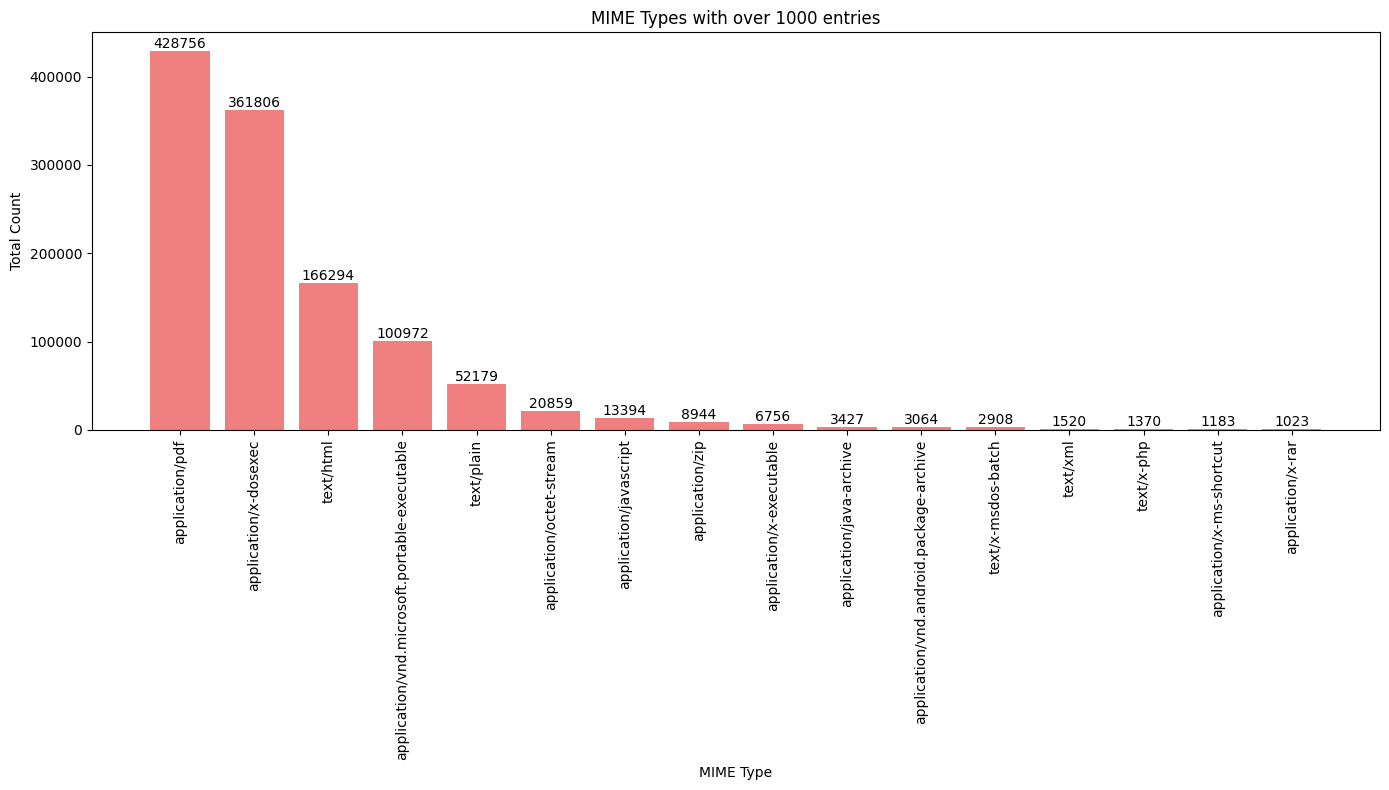

In [26]:
# Filter the data to select MIME types that have a total count between 2 and 20
count_between_2_and_20_df = mime_totals_df[(mime_totals_df['Total Count'] >= 1000)]

# Plot the bar chart for the top 10 most common MIME types
plt.figure(figsize=(14, 8))
bars = plt.bar(top_10['MIME Type'], top_10['Total Count'], color='skyblue')
plt.title('Top 10 Most Common MIME Types')
plt.xlabel('MIME Type')
plt.ylabel('Total Count')
plt.xticks(rotation=90)

# Add the count value on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Plot the bar chart for MIME types with a count between 2 and 20
plt.figure(figsize=(14, 8))
bars = plt.bar(count_between_2_and_20_df['MIME Type'], count_between_2_and_20_df['Total Count'], color='lightcoral')
plt.title('MIME Types with over 1000 entries')
plt.xlabel('MIME Type')
plt.ylabel('Total Count')
plt.xticks(rotation=90)

# Add the count value on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

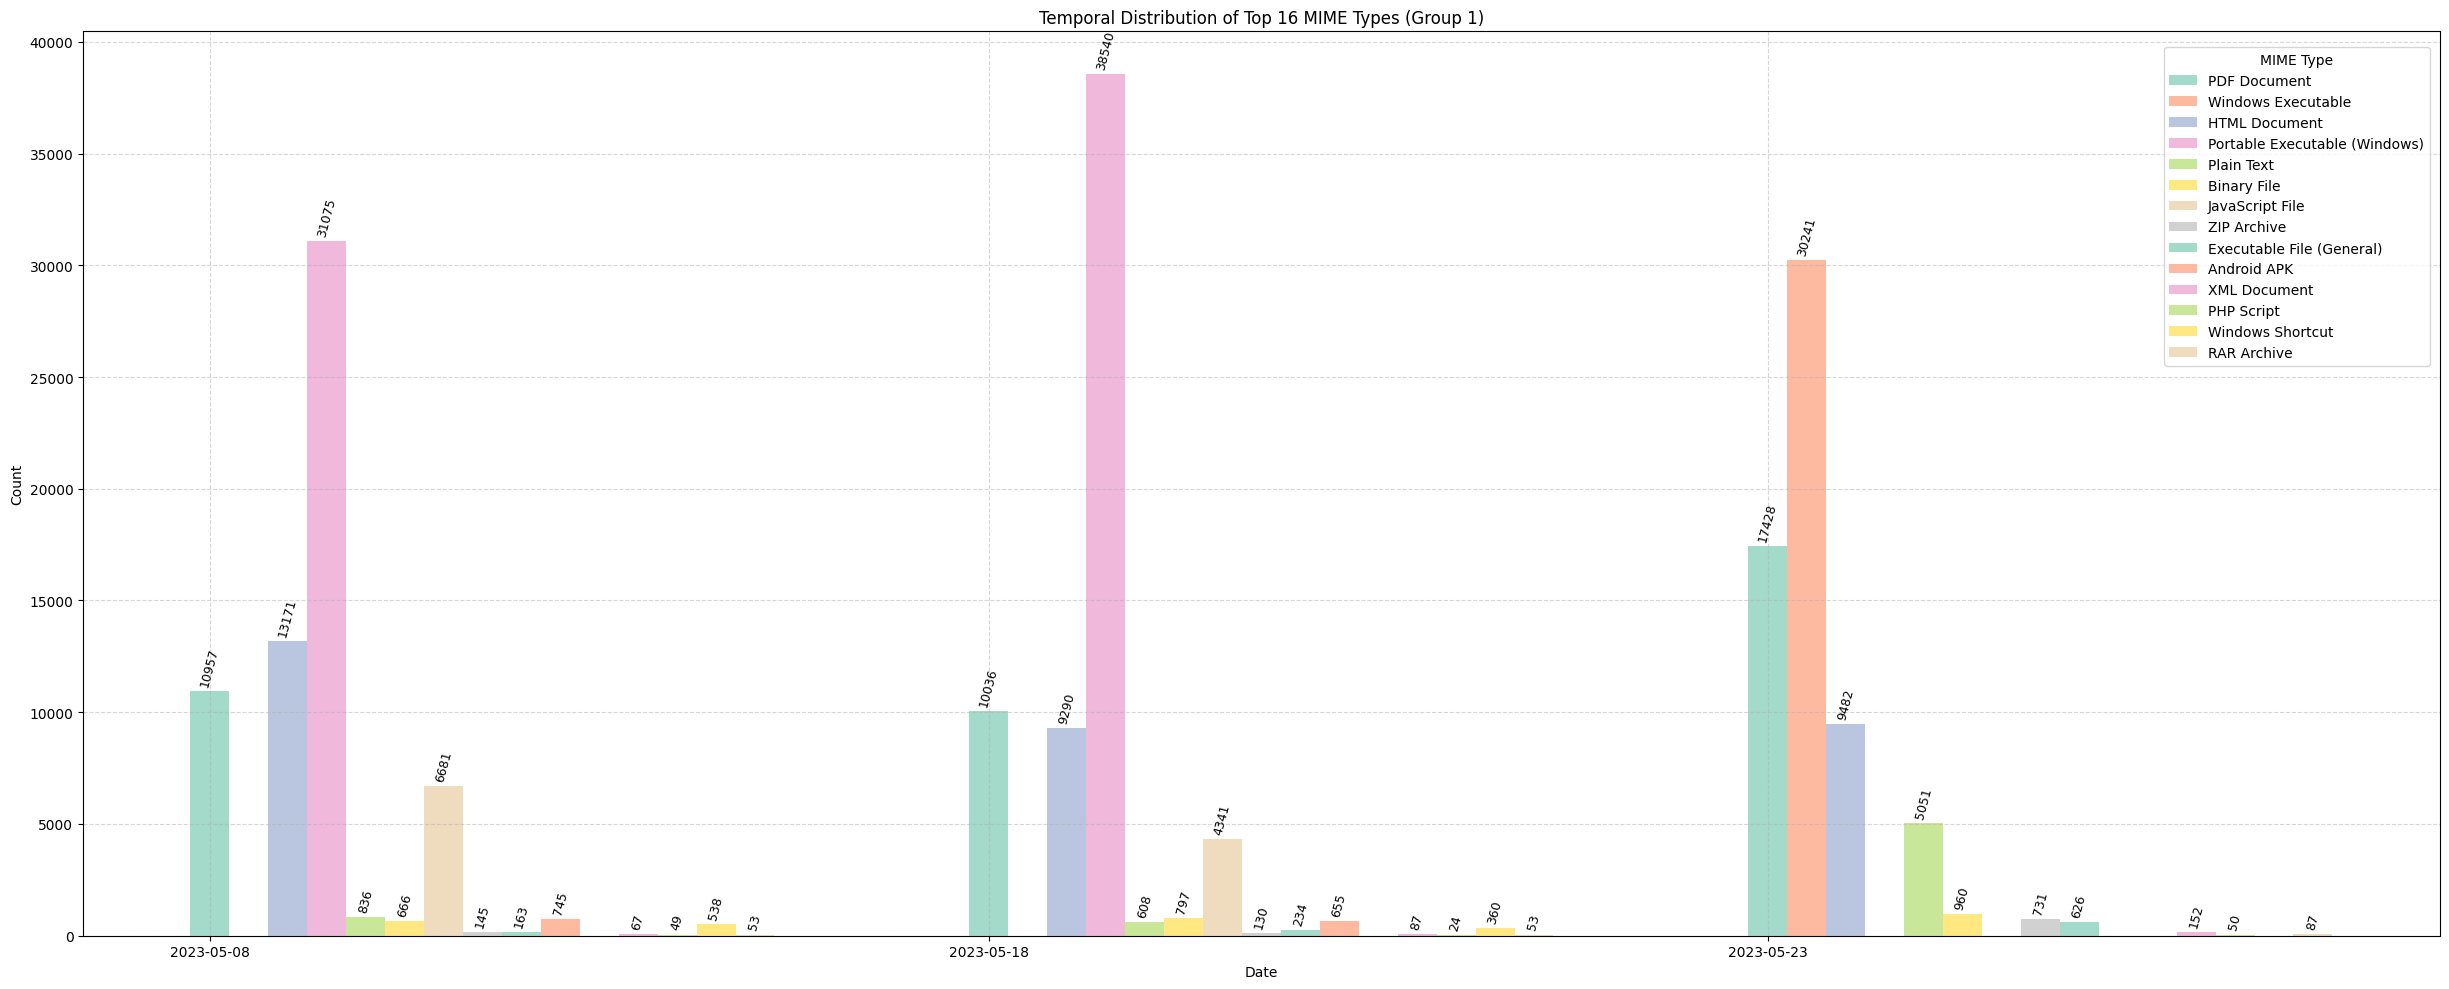

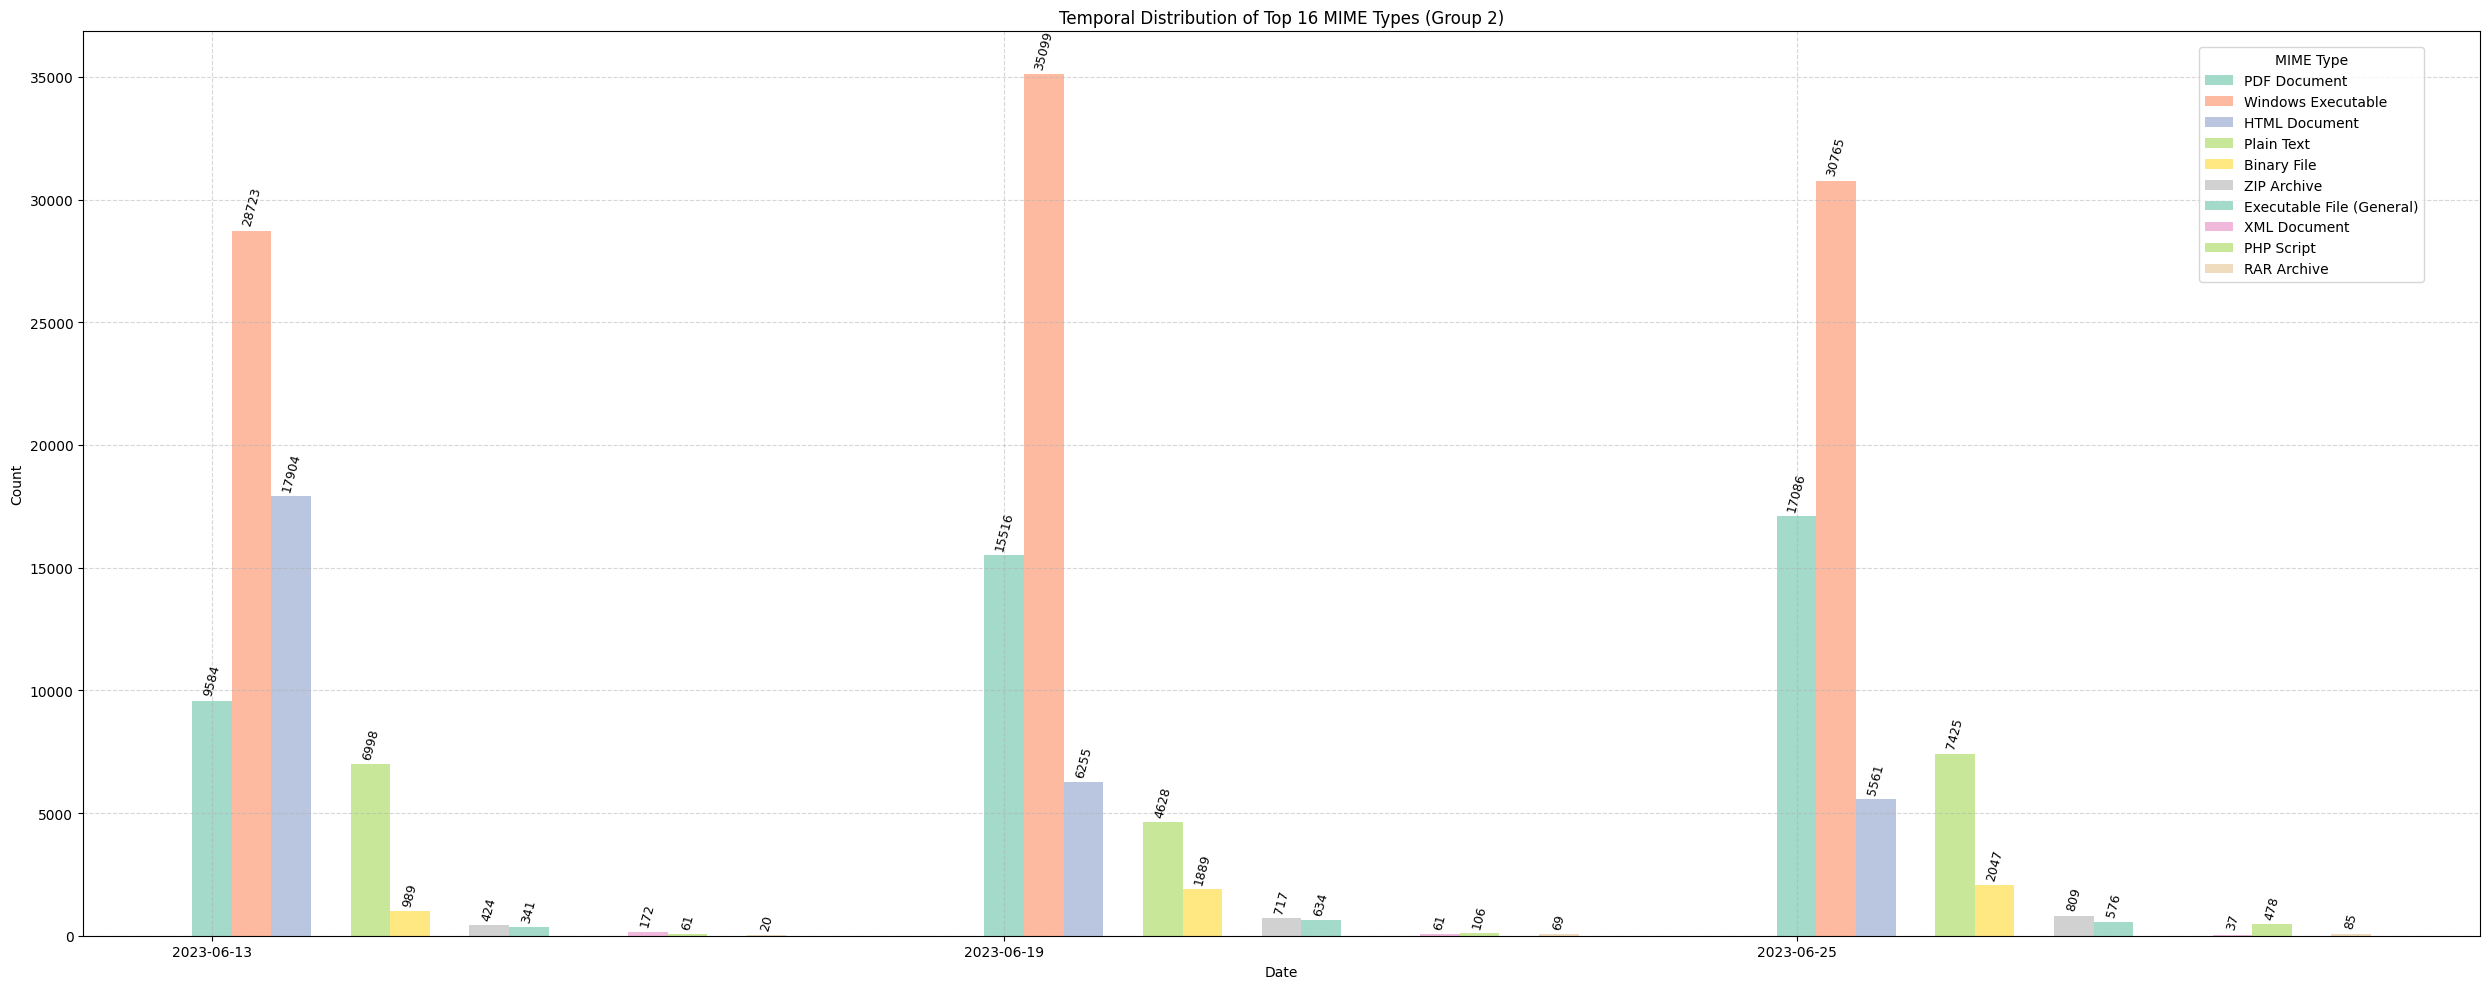

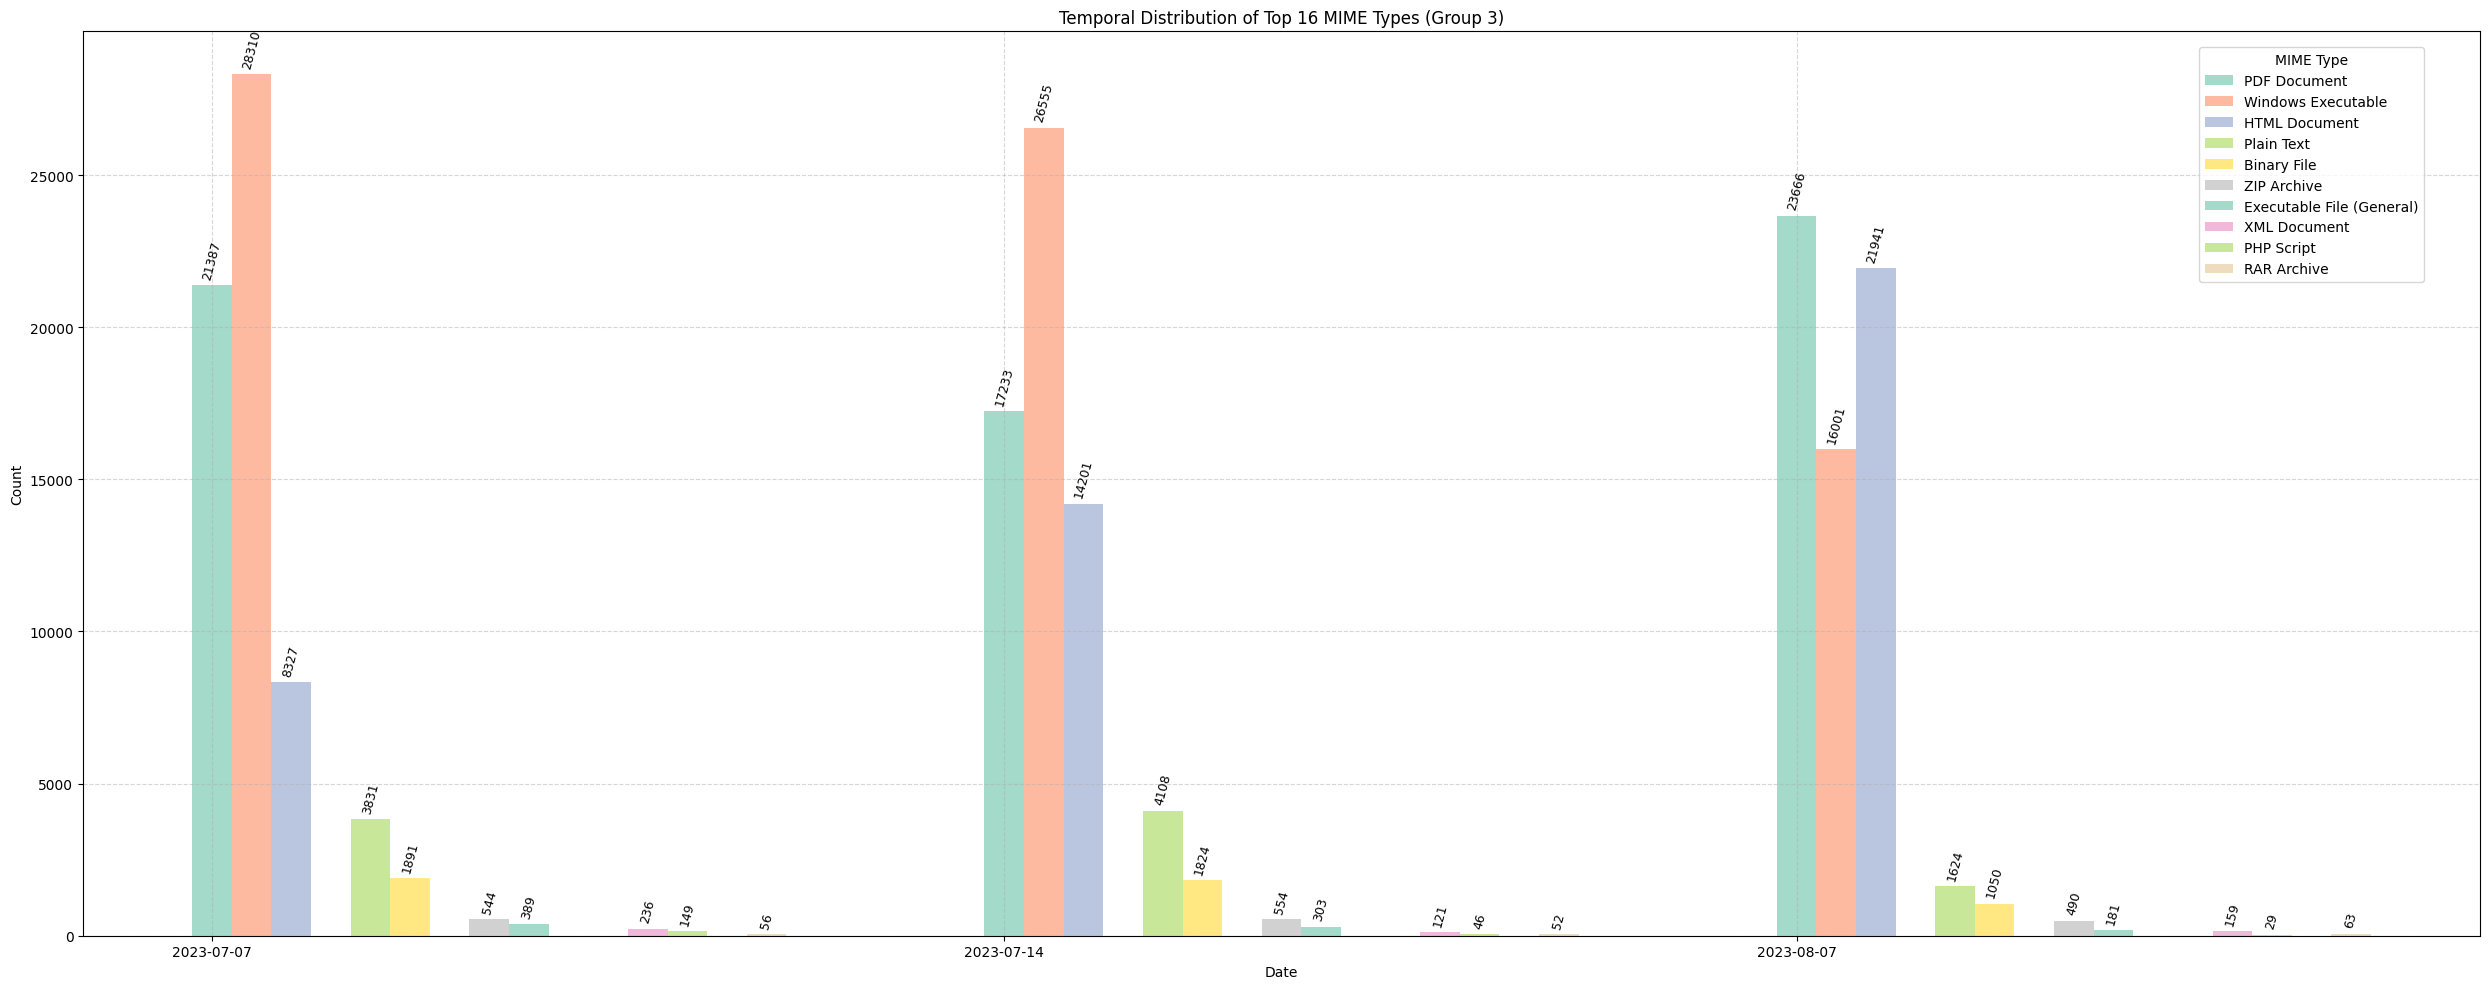

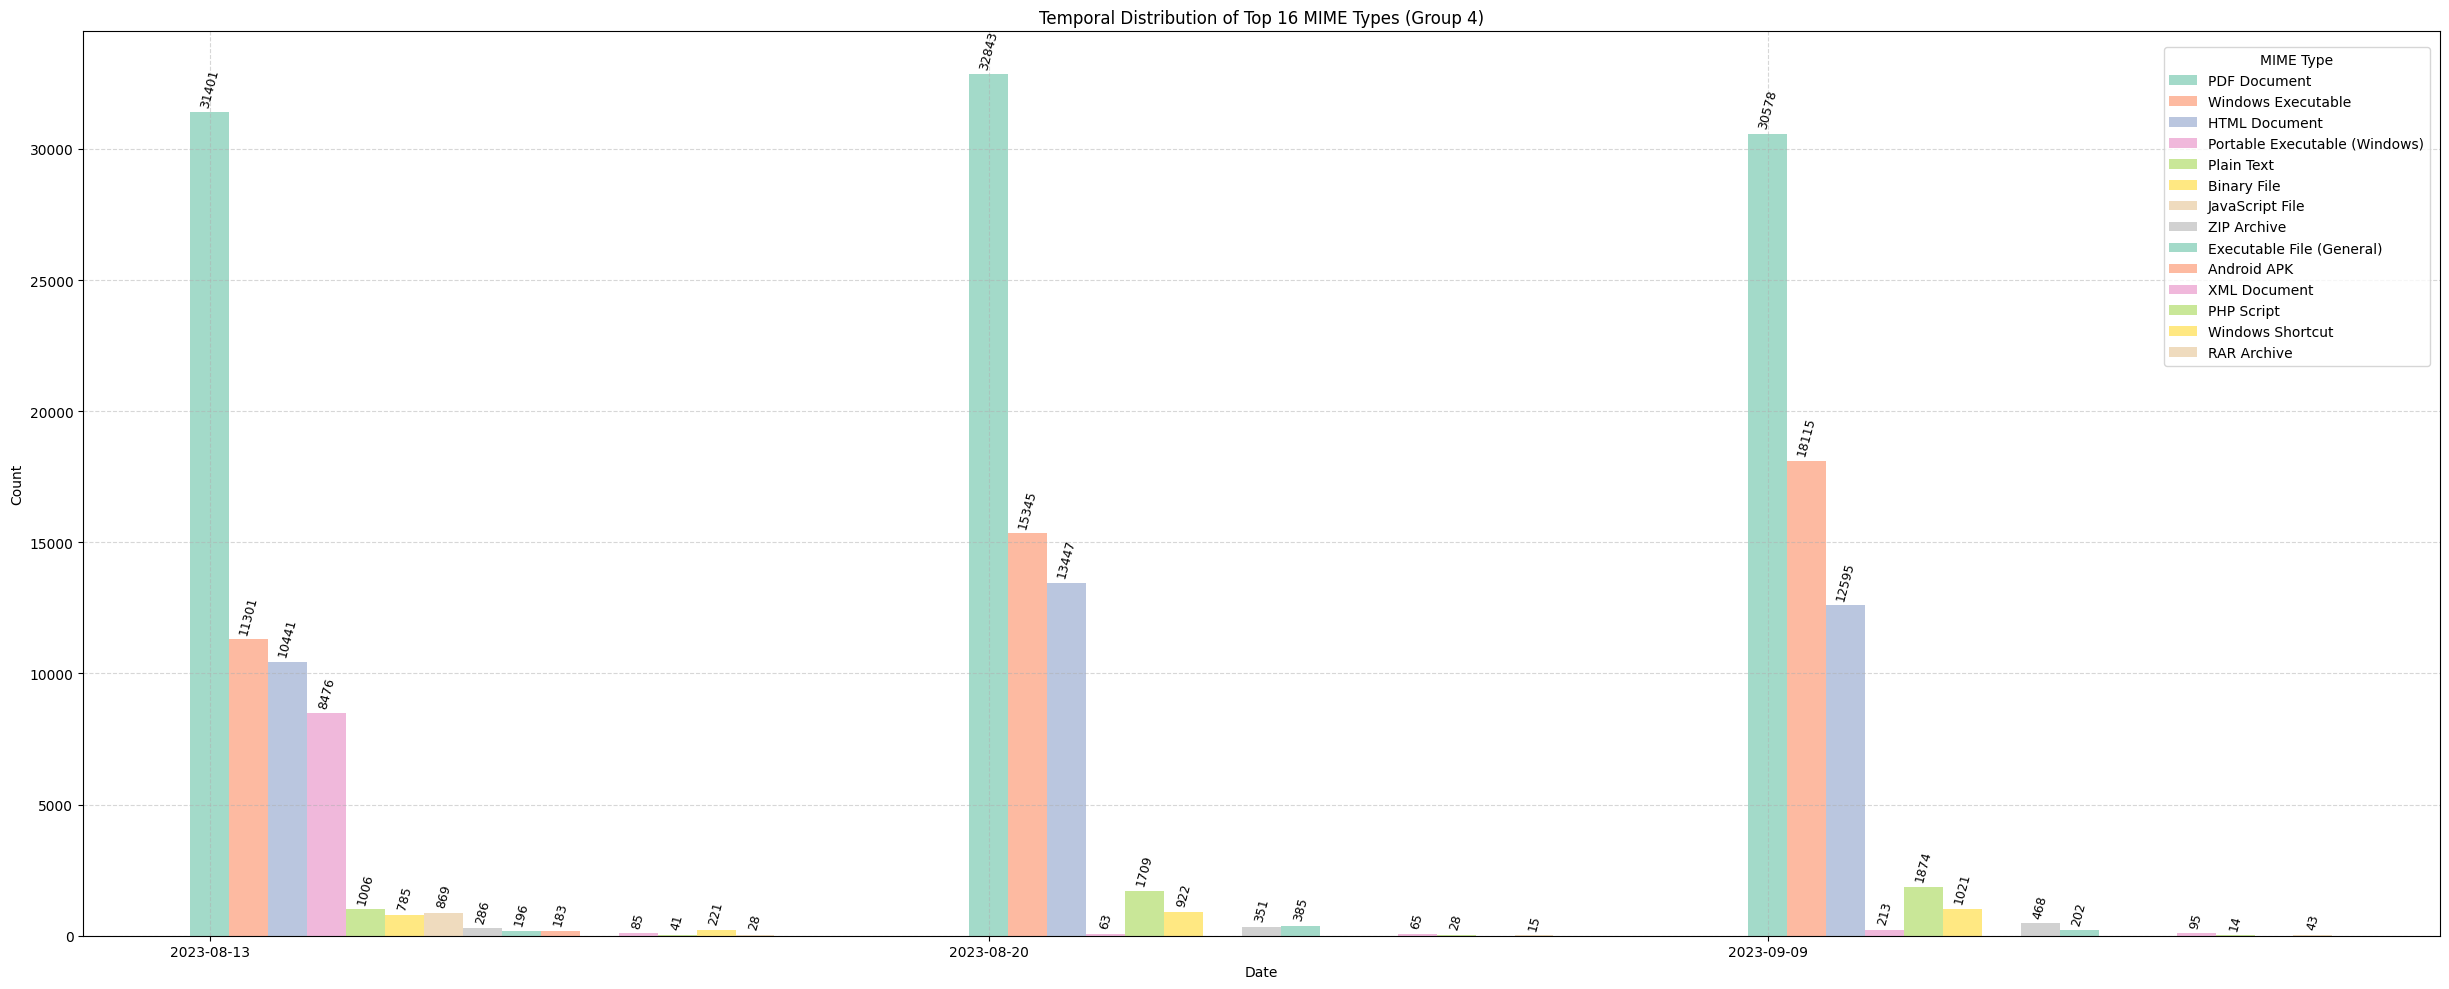

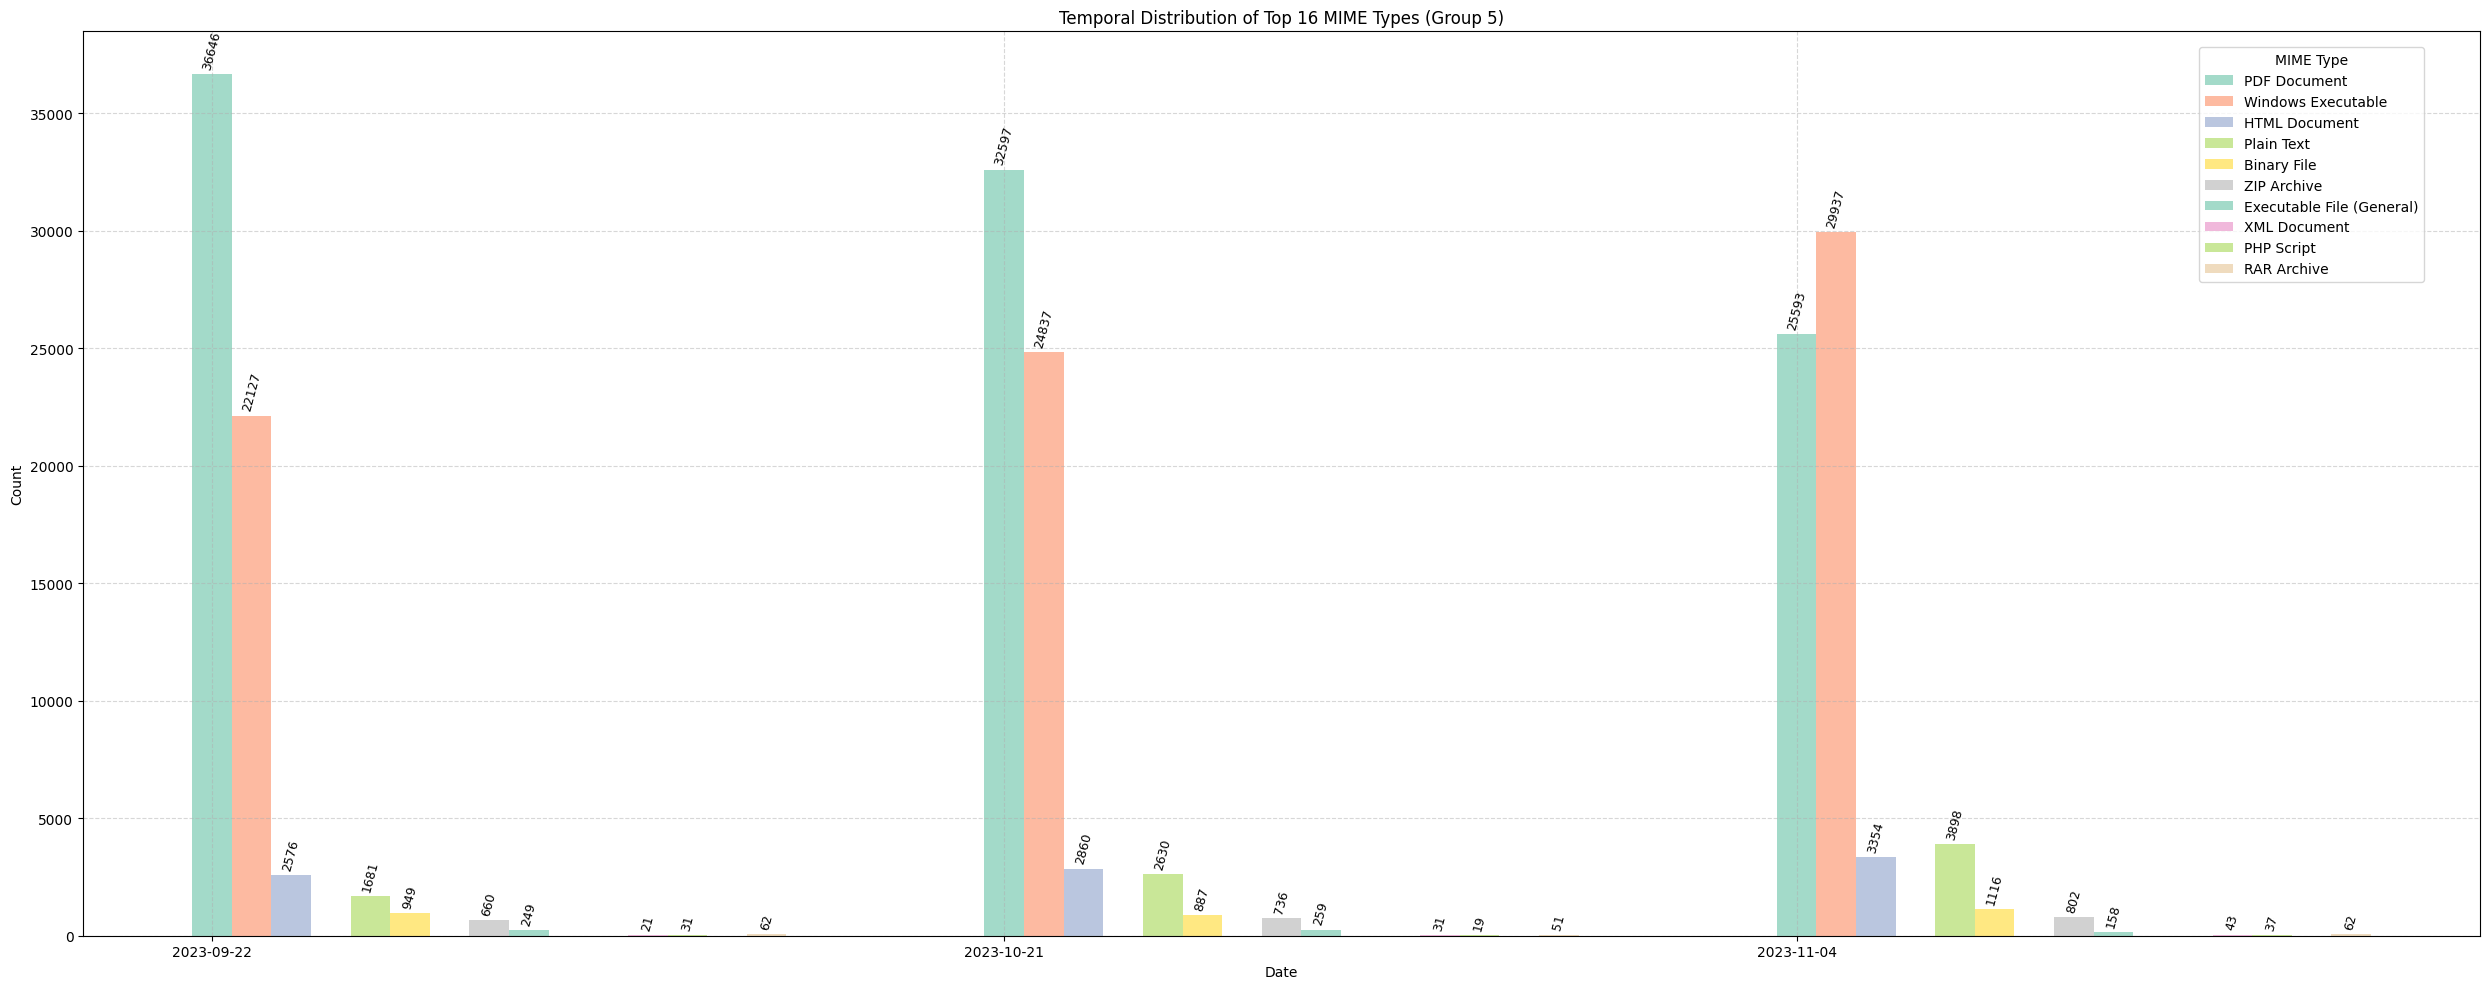

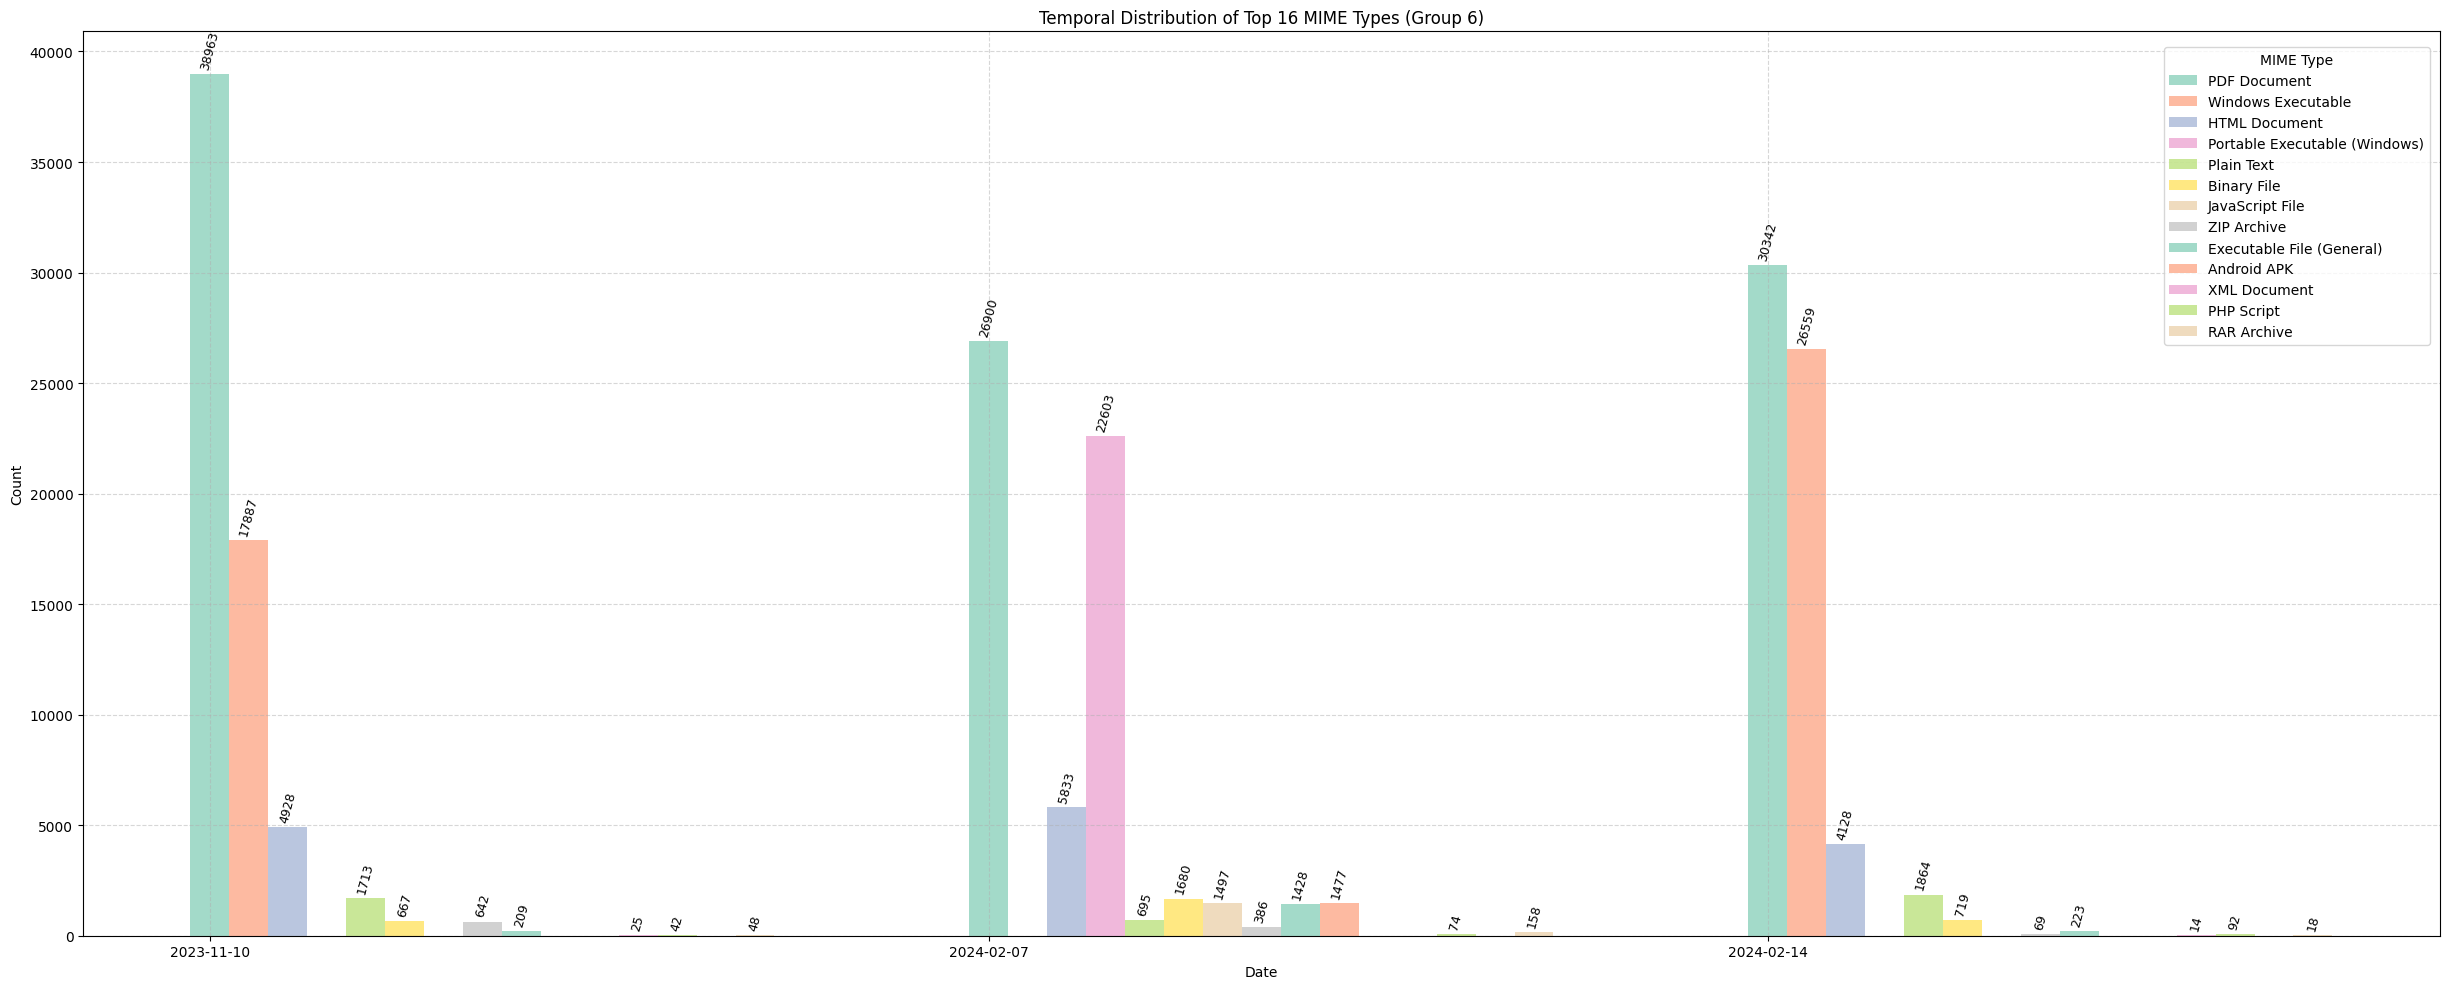

In [27]:

# Directory containing the CSV files
directory = './TypeCounts/'

# Dictionary to store data for temporal plots
temporal_data_16 = {}

# Function to read a CSV file and process it
def read_mime_counts(file_path):
    df = pd.read_csv(file_path)
    # Split column string into separate columns if necessary
    if 'Tipo MIME,Count,Arquivo' in df.columns:
        df[['MIME_type', 'Count', 'Arquivo']] = df['Tipo MIME,Count,Arquivo'].str.split(',', expand=True)
        df = df[['MIME_type', 'Count']]  # Retain only the needed columns
    
    # Convert 'Count' column to integer
    df['Count'] = df['Count'].astype(int)
    return df

# Iterate over all files in the directory
for filename in os.listdir(directory):
    if filename.startswith('mime_counts') and filename.endswith('.csv'):
        file_path = os.path.join(directory, filename)
        df = read_mime_counts(file_path)

        # Sort by count in descending order and get top 16
        df = df.sort_values(by='Count', ascending=False)
        top_16 = df.head(16)

        # Store data in dictionary for plotting
        for index, row in top_16.iterrows():
            mime_type = row['MIME_type']
            count = row['Count']
            if filename not in temporal_data_16:
                temporal_data_16[filename] = []
            temporal_data_16[filename].append((mime_type, count))

# Creating a mapping dictionary for renaming
mime_to_name_mapping = {
    'application/pdf': 'PDF Document',
    'application/x-dosexec': 'Windows Executable',
    'text/html': 'HTML Document',
    'application/vnd.microsoft.portable-executable': 'Portable Executable (Windows)',
    'text/plain': 'Plain Text',
    'application/octet-stream': 'Binary File',
    'application/javascript': 'JavaScript File',
    'application/zip': 'ZIP Archive',
    'application/x-executable': 'Executable File (General)',
    'application/vnd.android.package-archive': 'Android APK',
    'application/x-msdos-batch': 'Batch Script',
    'text/xml': 'XML Document',
    'text/x-php': 'PHP Script',
    'application/x-ms-shortcut': 'Windows Shortcut',
    'application/x-rar': 'RAR Archive'
}

# Define a fixed color palette for all MIME types
# This will ensure the same color order for each MIME type across all plots
colors = sns.color_palette("Set2", len(mime_to_name_mapping))  # Using Set2 palette from seaborn

# Create a mapping from MIME type to color
mime_type_to_color = {mime: colors[i] for i, mime in enumerate(mime_to_name_mapping.values())}

# Plotting grouped data
files = list(temporal_data_16.keys())
file_groups = [files[i:i + 3] for i in range(0, len(files), 3)]

# Iterate over each group of files and create a plot for each group
for i, file_group in enumerate(file_groups):
    temporal_data_group = {key: [] for key in mime_to_name_mapping.values()}
    
    for file in file_group:
        date = pd.to_datetime(virusshare_dates[file])
        mime_list = temporal_data_16[file]
        
        for mime_type, count in mime_list:
            if mime_type in mime_to_name_mapping:
                conventional_name = mime_to_name_mapping[mime_type]
                temporal_data_group[conventional_name].append((date, count))
    
    # Prepare figure for the bar graph
    plt.figure(figsize=(25, 10))
    bar_width = 0.05
    
    all_dates = set()
    for data in temporal_data_group.values():
        if data:
            dates, _ = zip(*data)
            all_dates.update(dates)
    
    all_dates = sorted(all_dates)
    date_to_index = {date: idx for idx, date in enumerate(all_dates)}
    
    for idx, (mime_type, data) in enumerate(temporal_data_group.items()):
        data = sorted(data, key=lambda x: x[0])
        if data:
            dates, counts = zip(*data)
            date_indices = [date_to_index[date] for date in dates]
            # Use the fixed color from mime_type_to_color
            bars = plt.bar([x + idx * bar_width for x in date_indices], counts, width=bar_width, 
                           label=mime_type, alpha=0.6, color=mime_type_to_color[mime_type])
            
            # Adding the count labels on top of the bars with modifications
            for bar in bars:
                yval = bar.get_height()
                xval = bar.get_x() + bar.get_width() / 2
                
                # Vary the height a bit to avoid overlap and tilt the number
                offset = 150  # Randomly adjust the offset to prevent overlap
                rotated_angle = 75  # Random angle for rotation to make numbers more readable
                
                # Use plt.text to add the number with tilting and different height positioning
                plt.text(xval, yval + offset, int(yval), ha='center', va='bottom', fontsize=9, rotation=rotated_angle)
                
                
    plt.xticks(range(len(all_dates)), [date.strftime('%Y-%m-%d') for date in all_dates])
    plt.title(f'Temporal Distribution of Top 16 MIME Types (Group {i + 1})')
    plt.xlabel('Date')
    plt.ylabel('Count')
    plt.legend(title='MIME Type', bbox_to_anchor=(0.88, 0.99), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    
    plt.show()


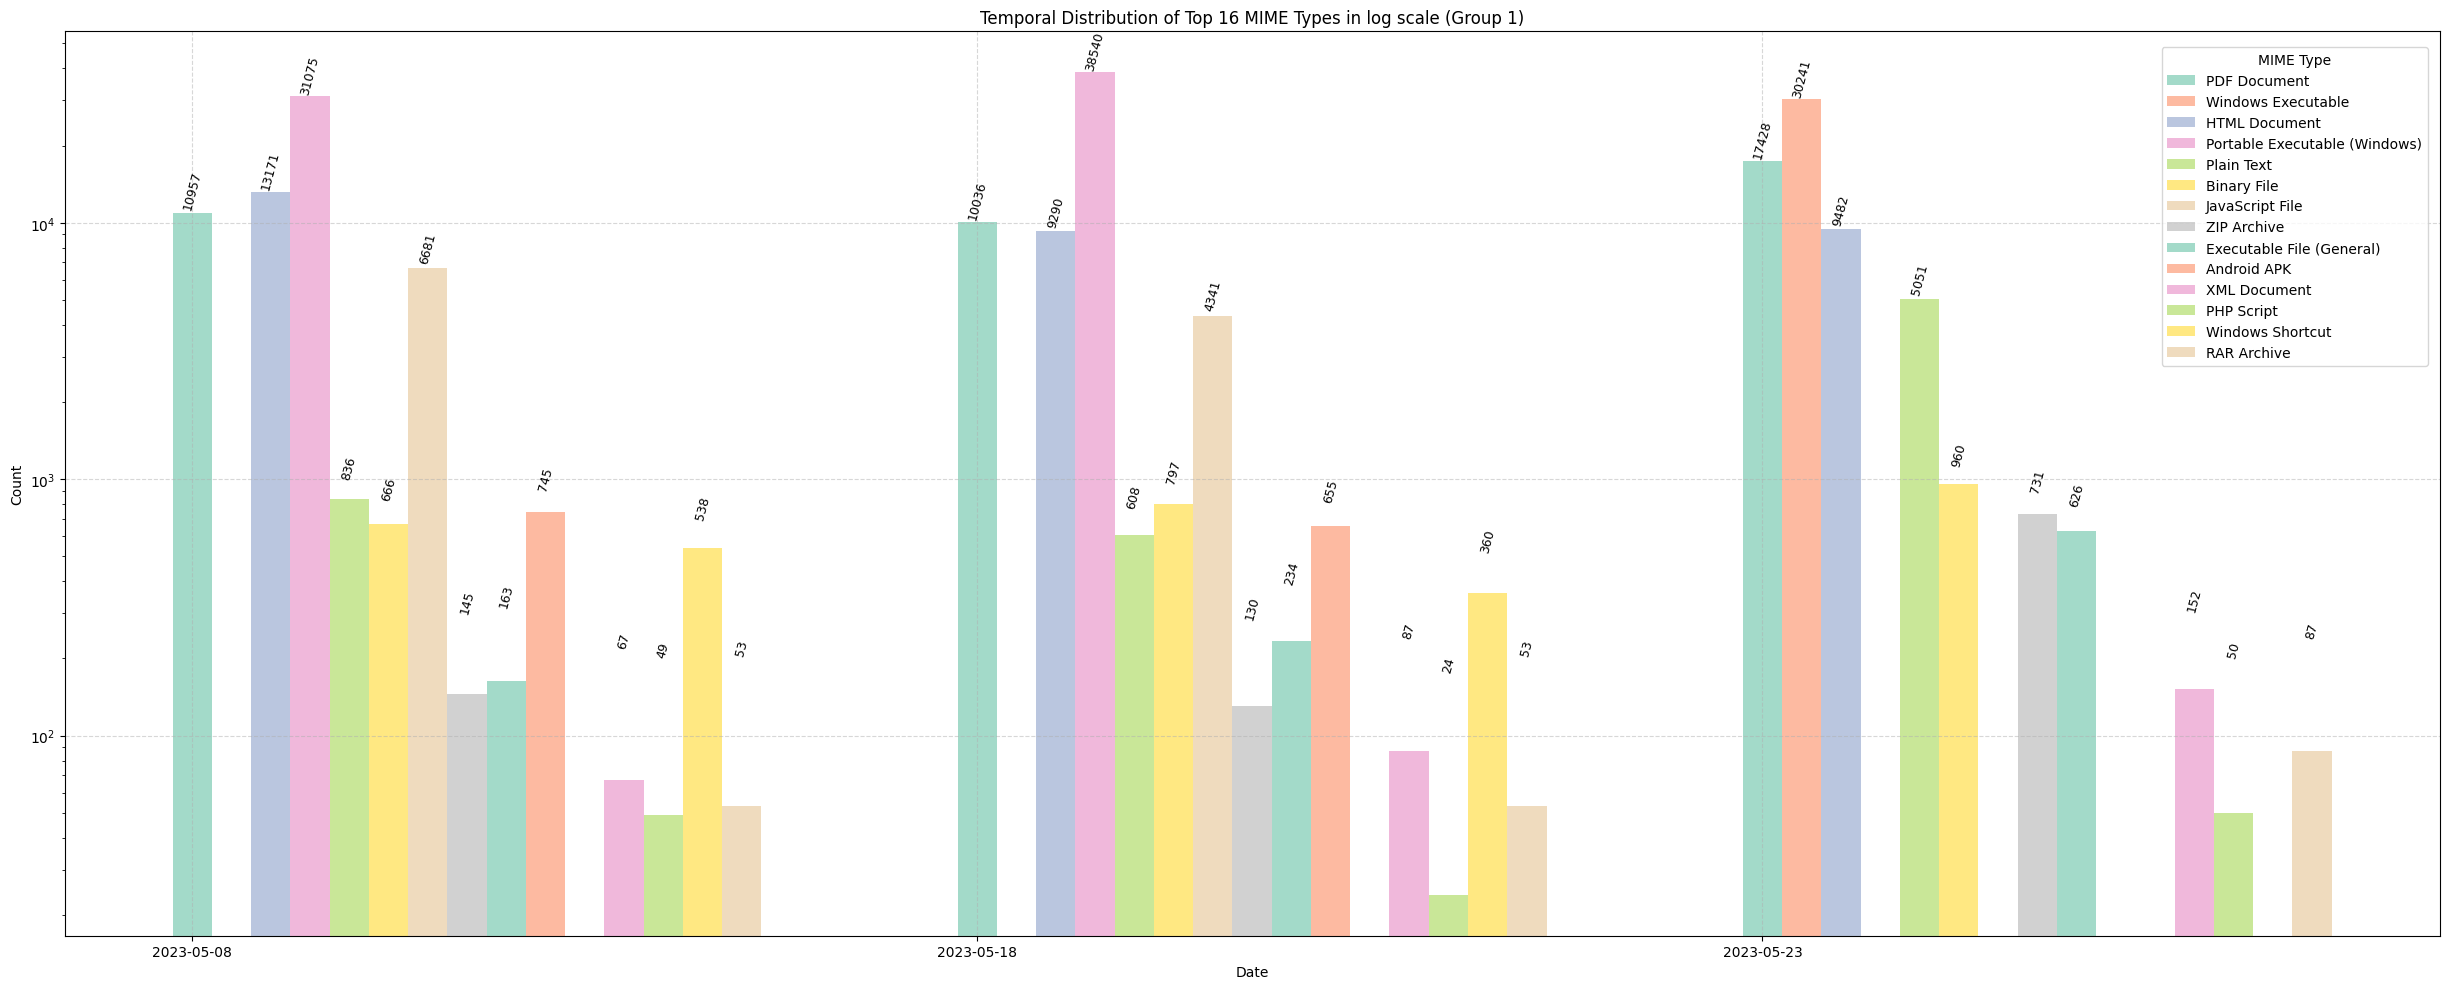

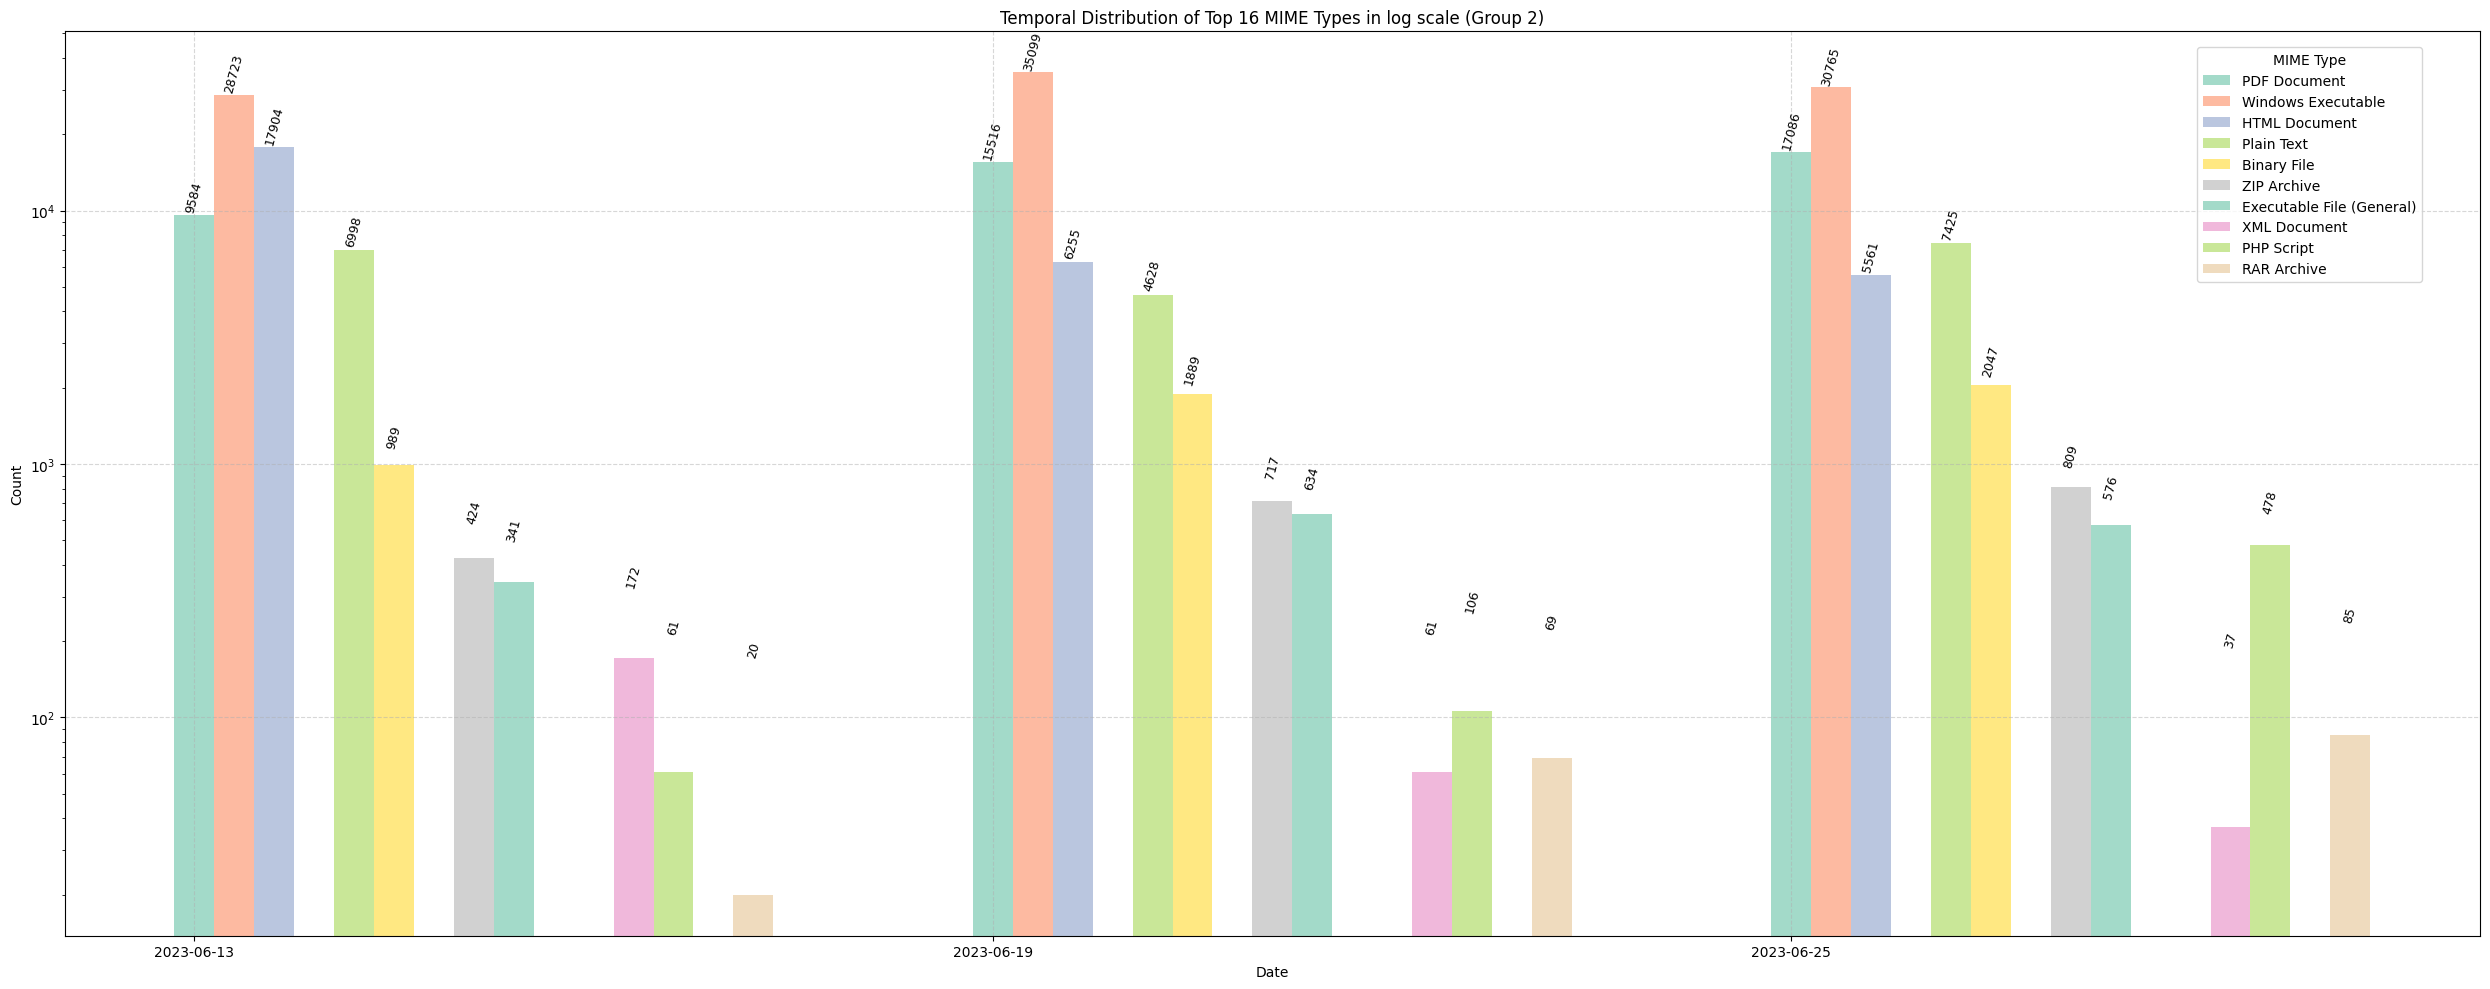

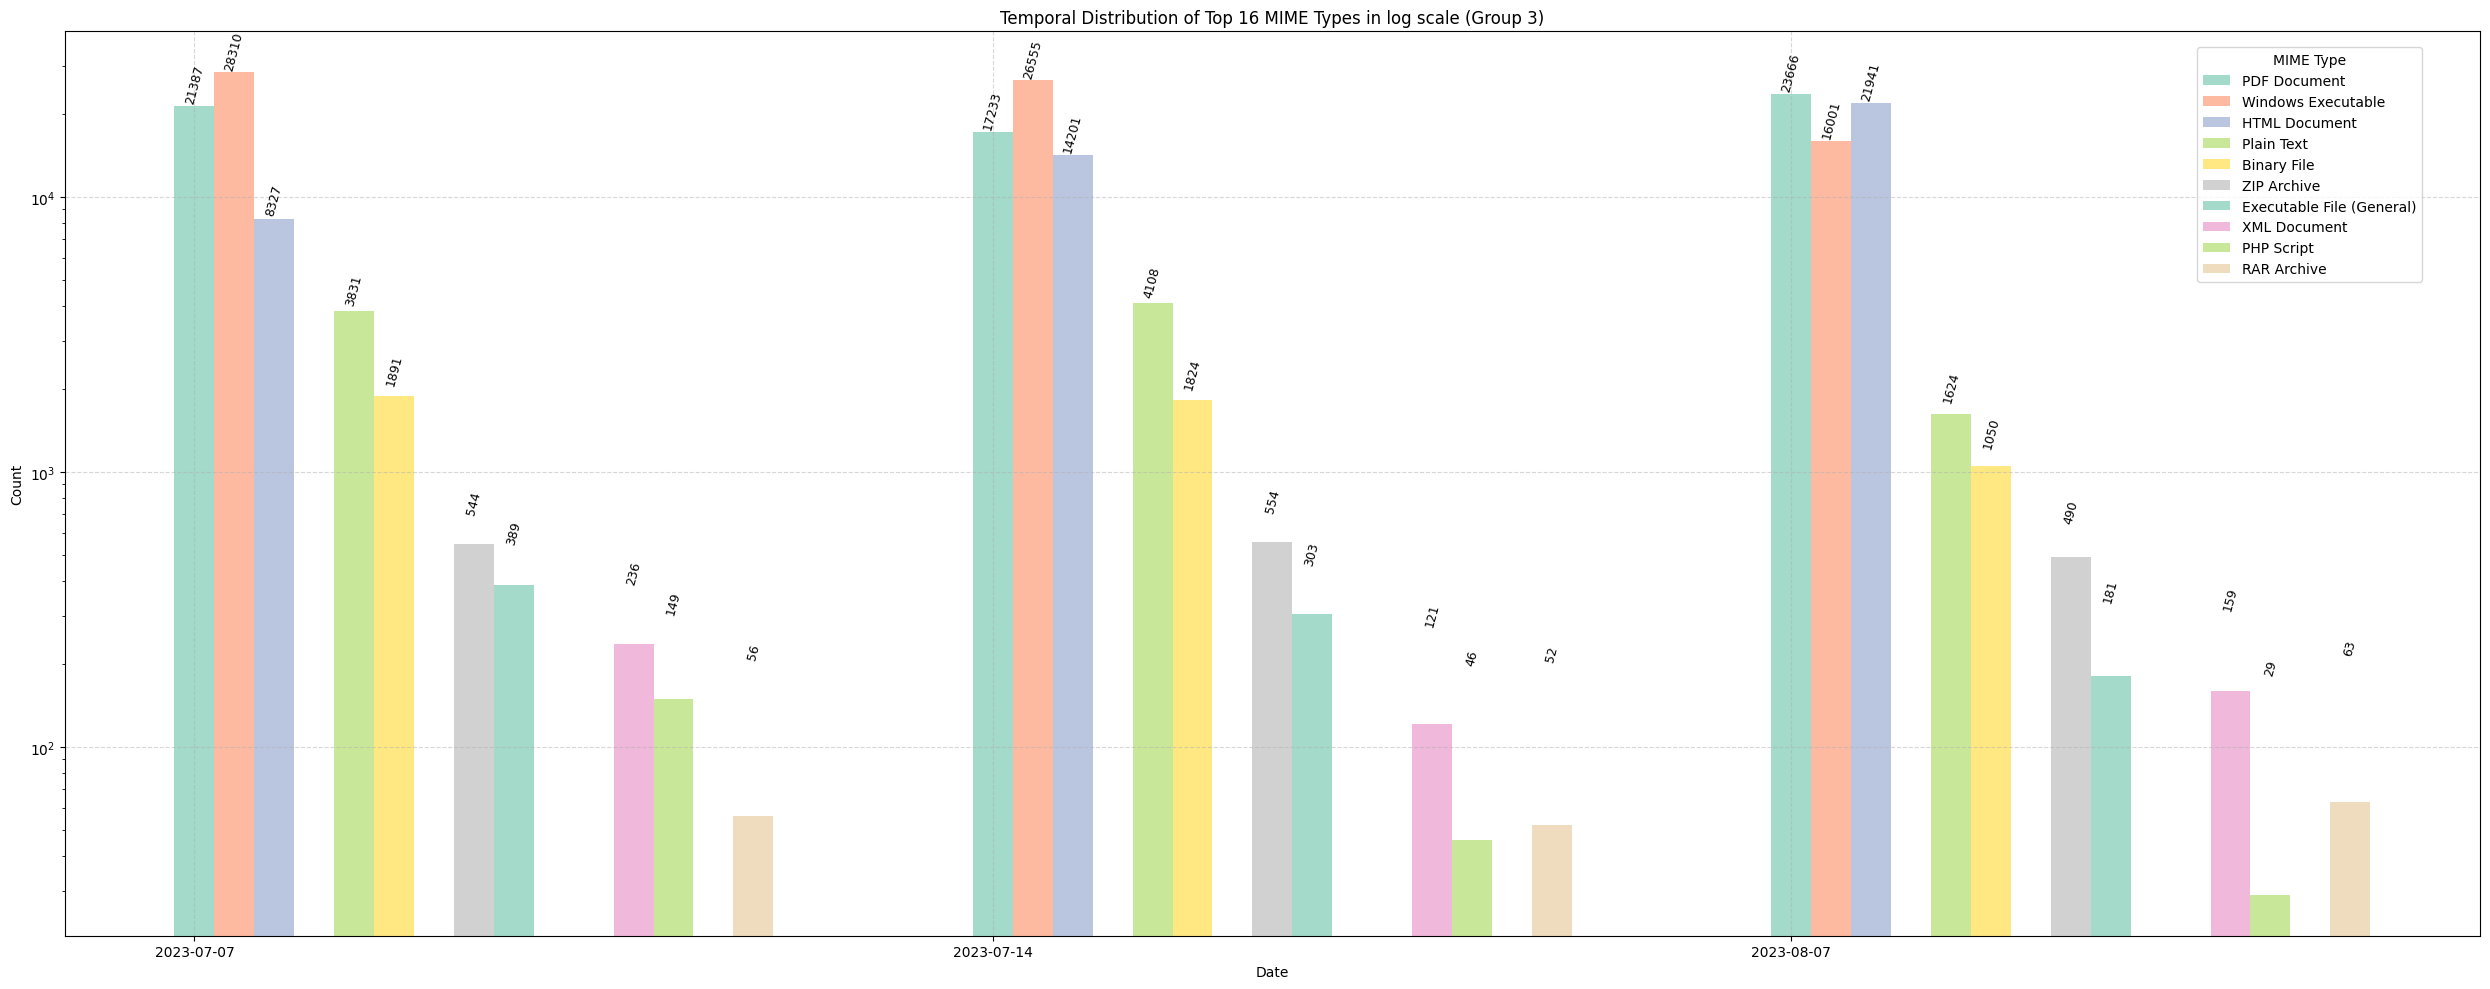

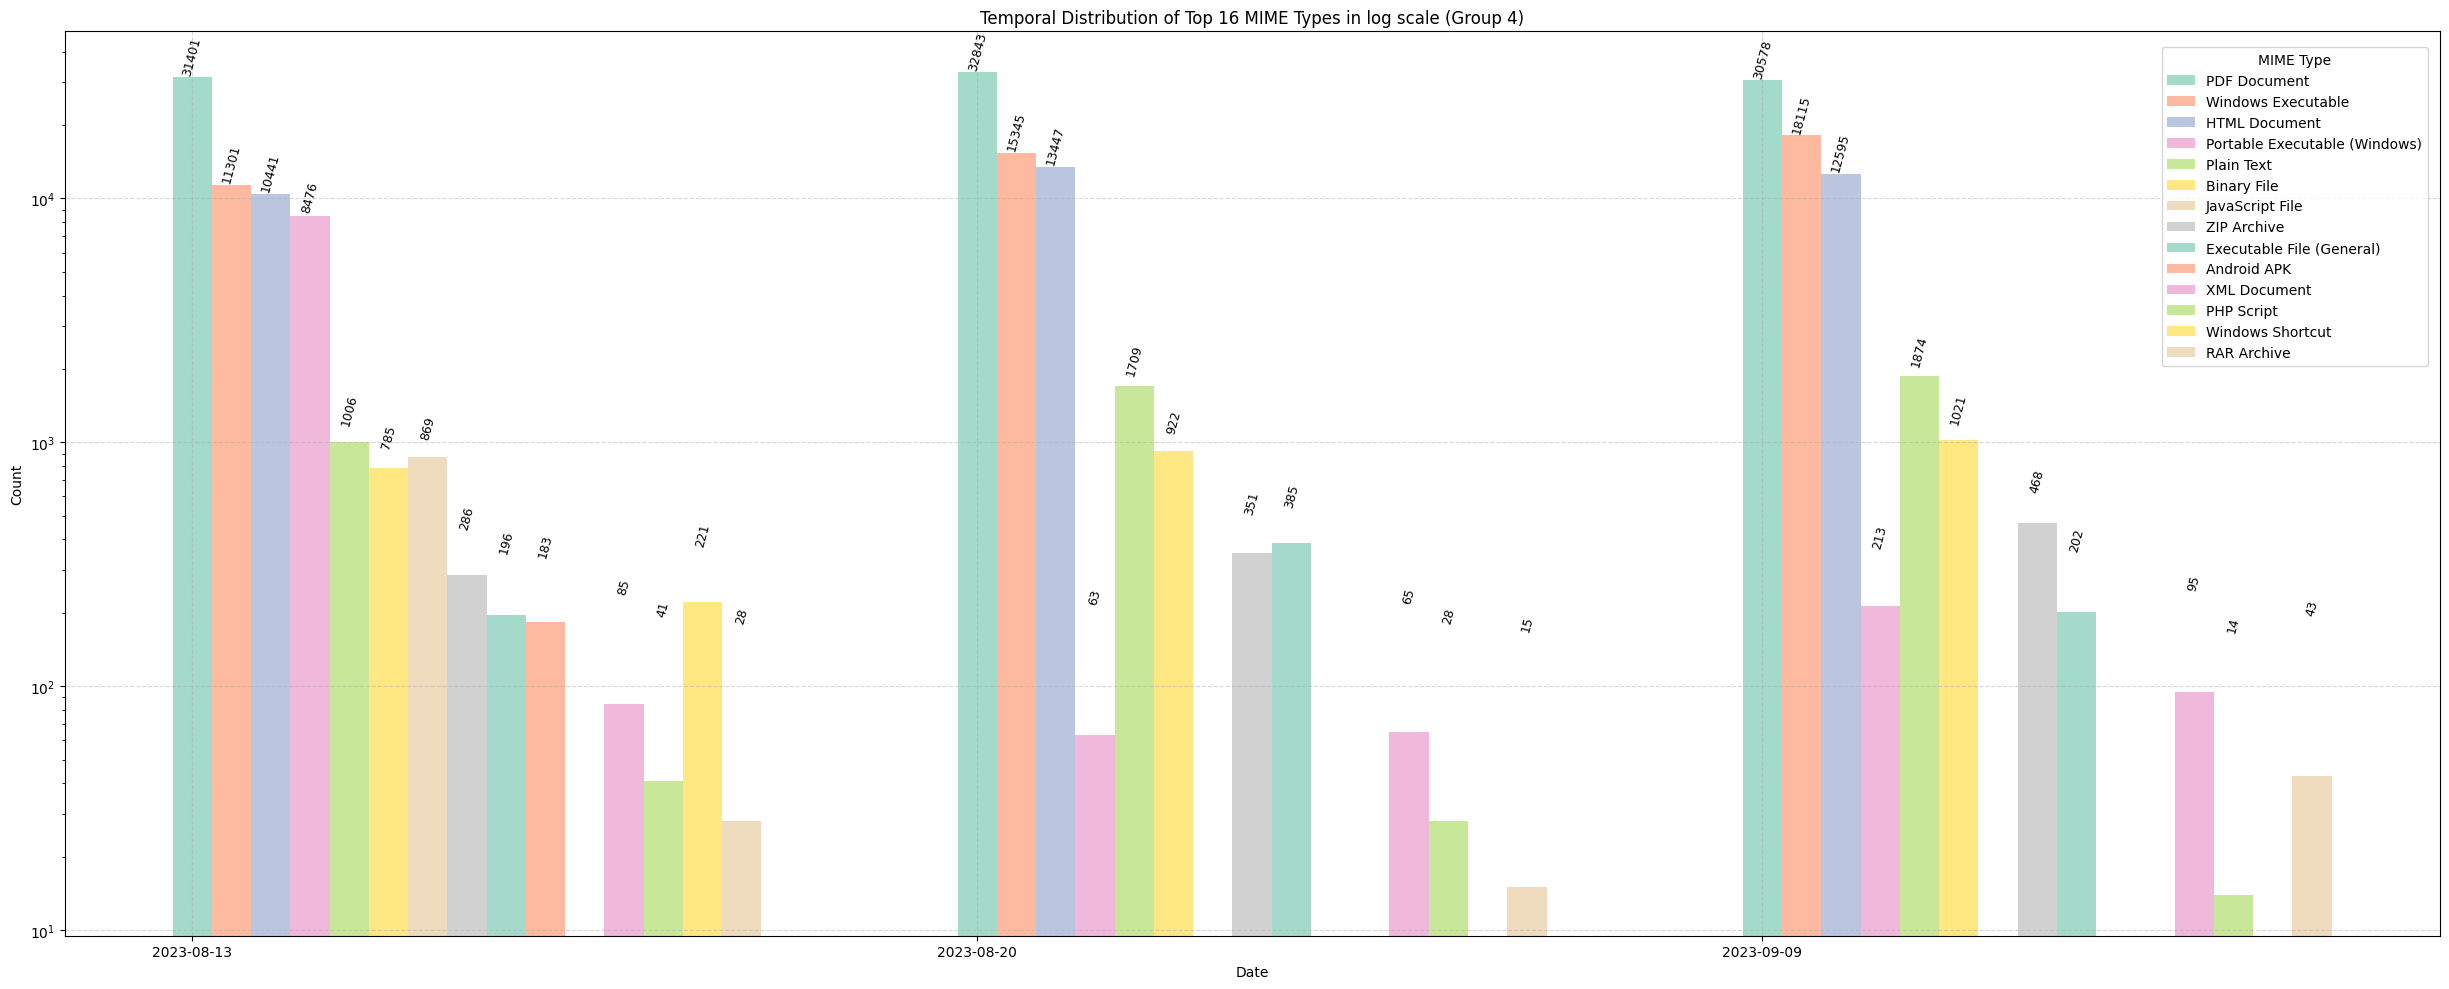

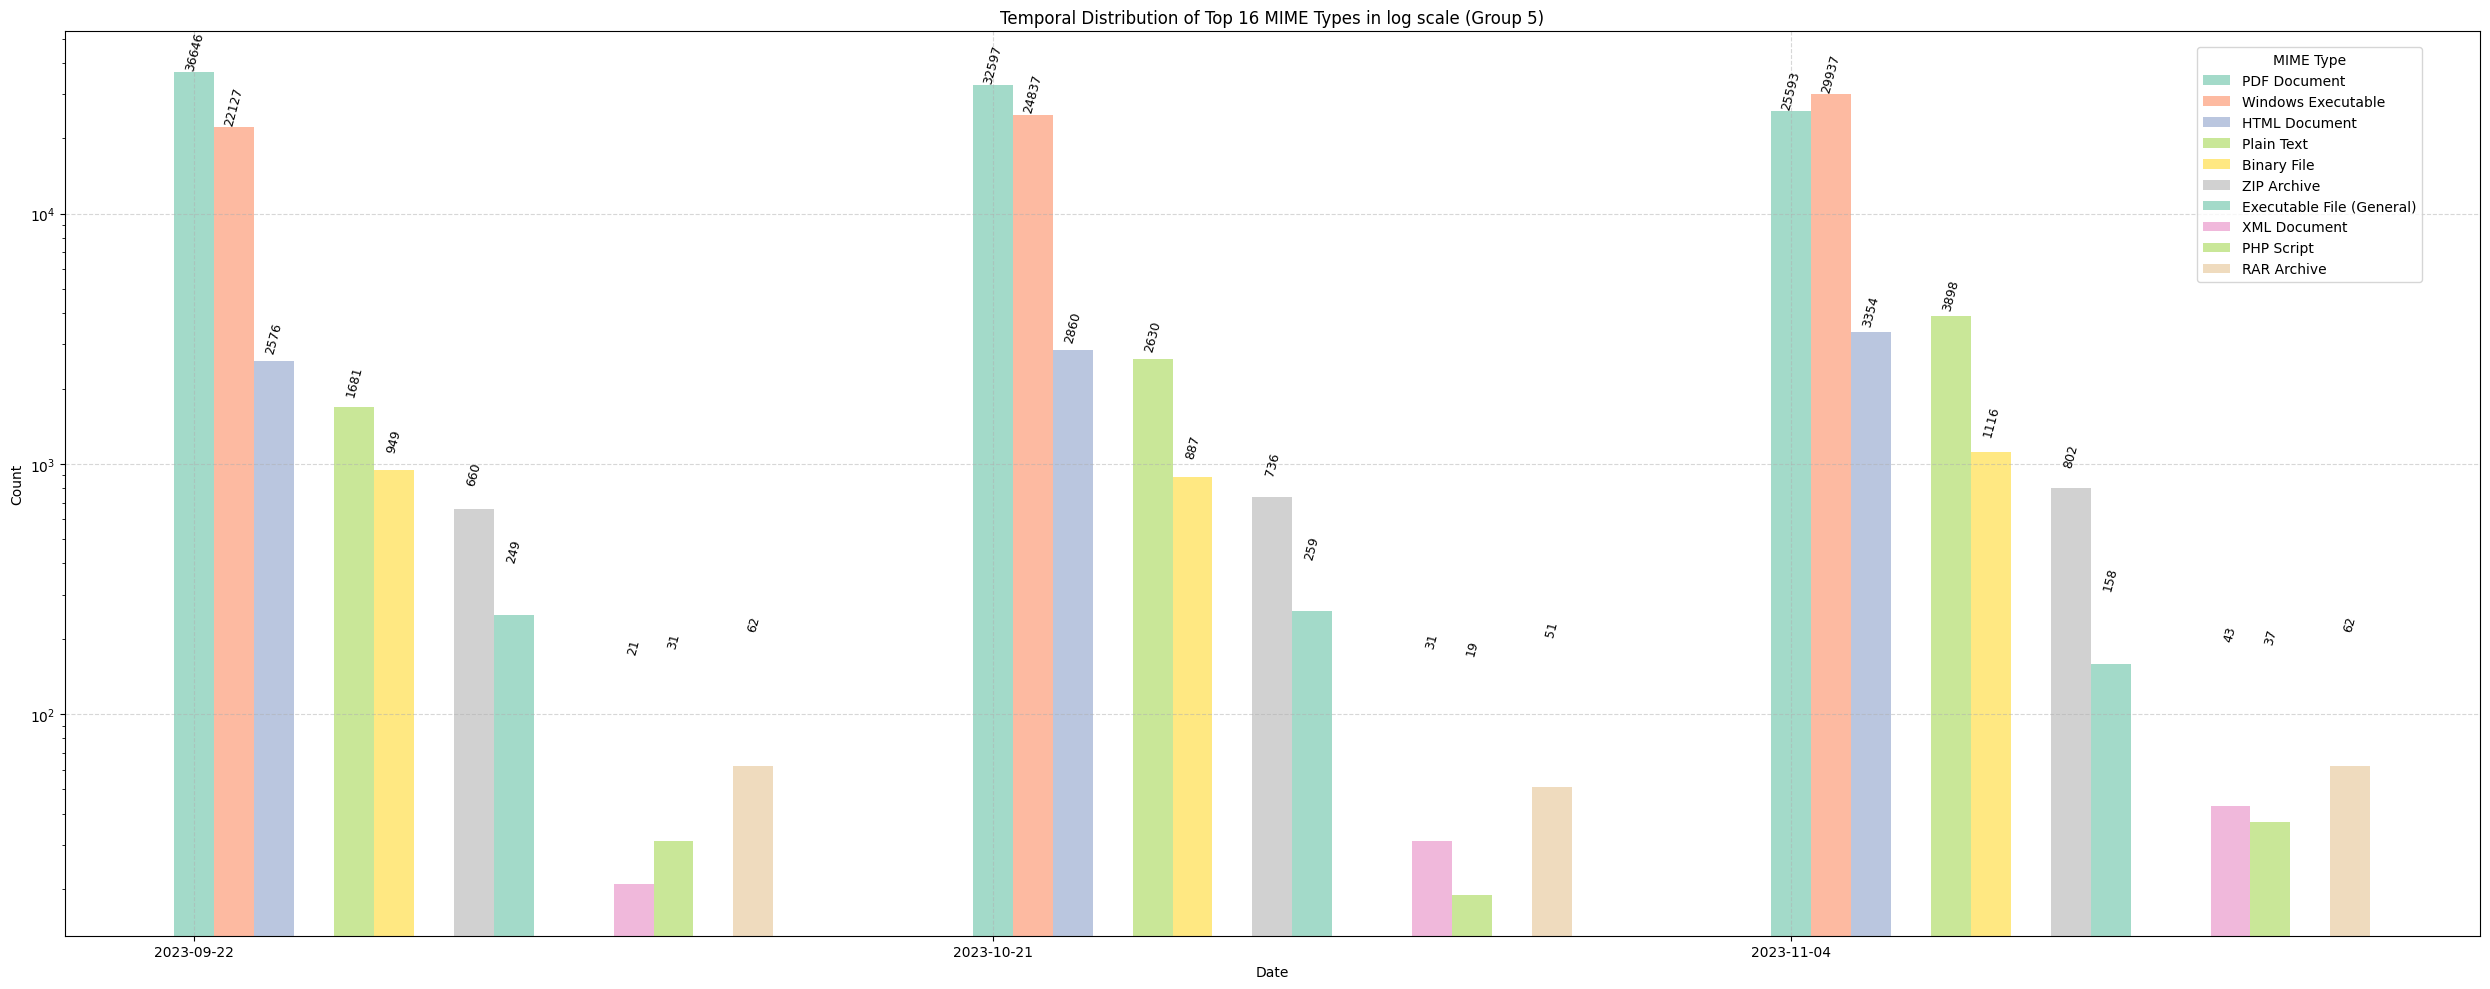

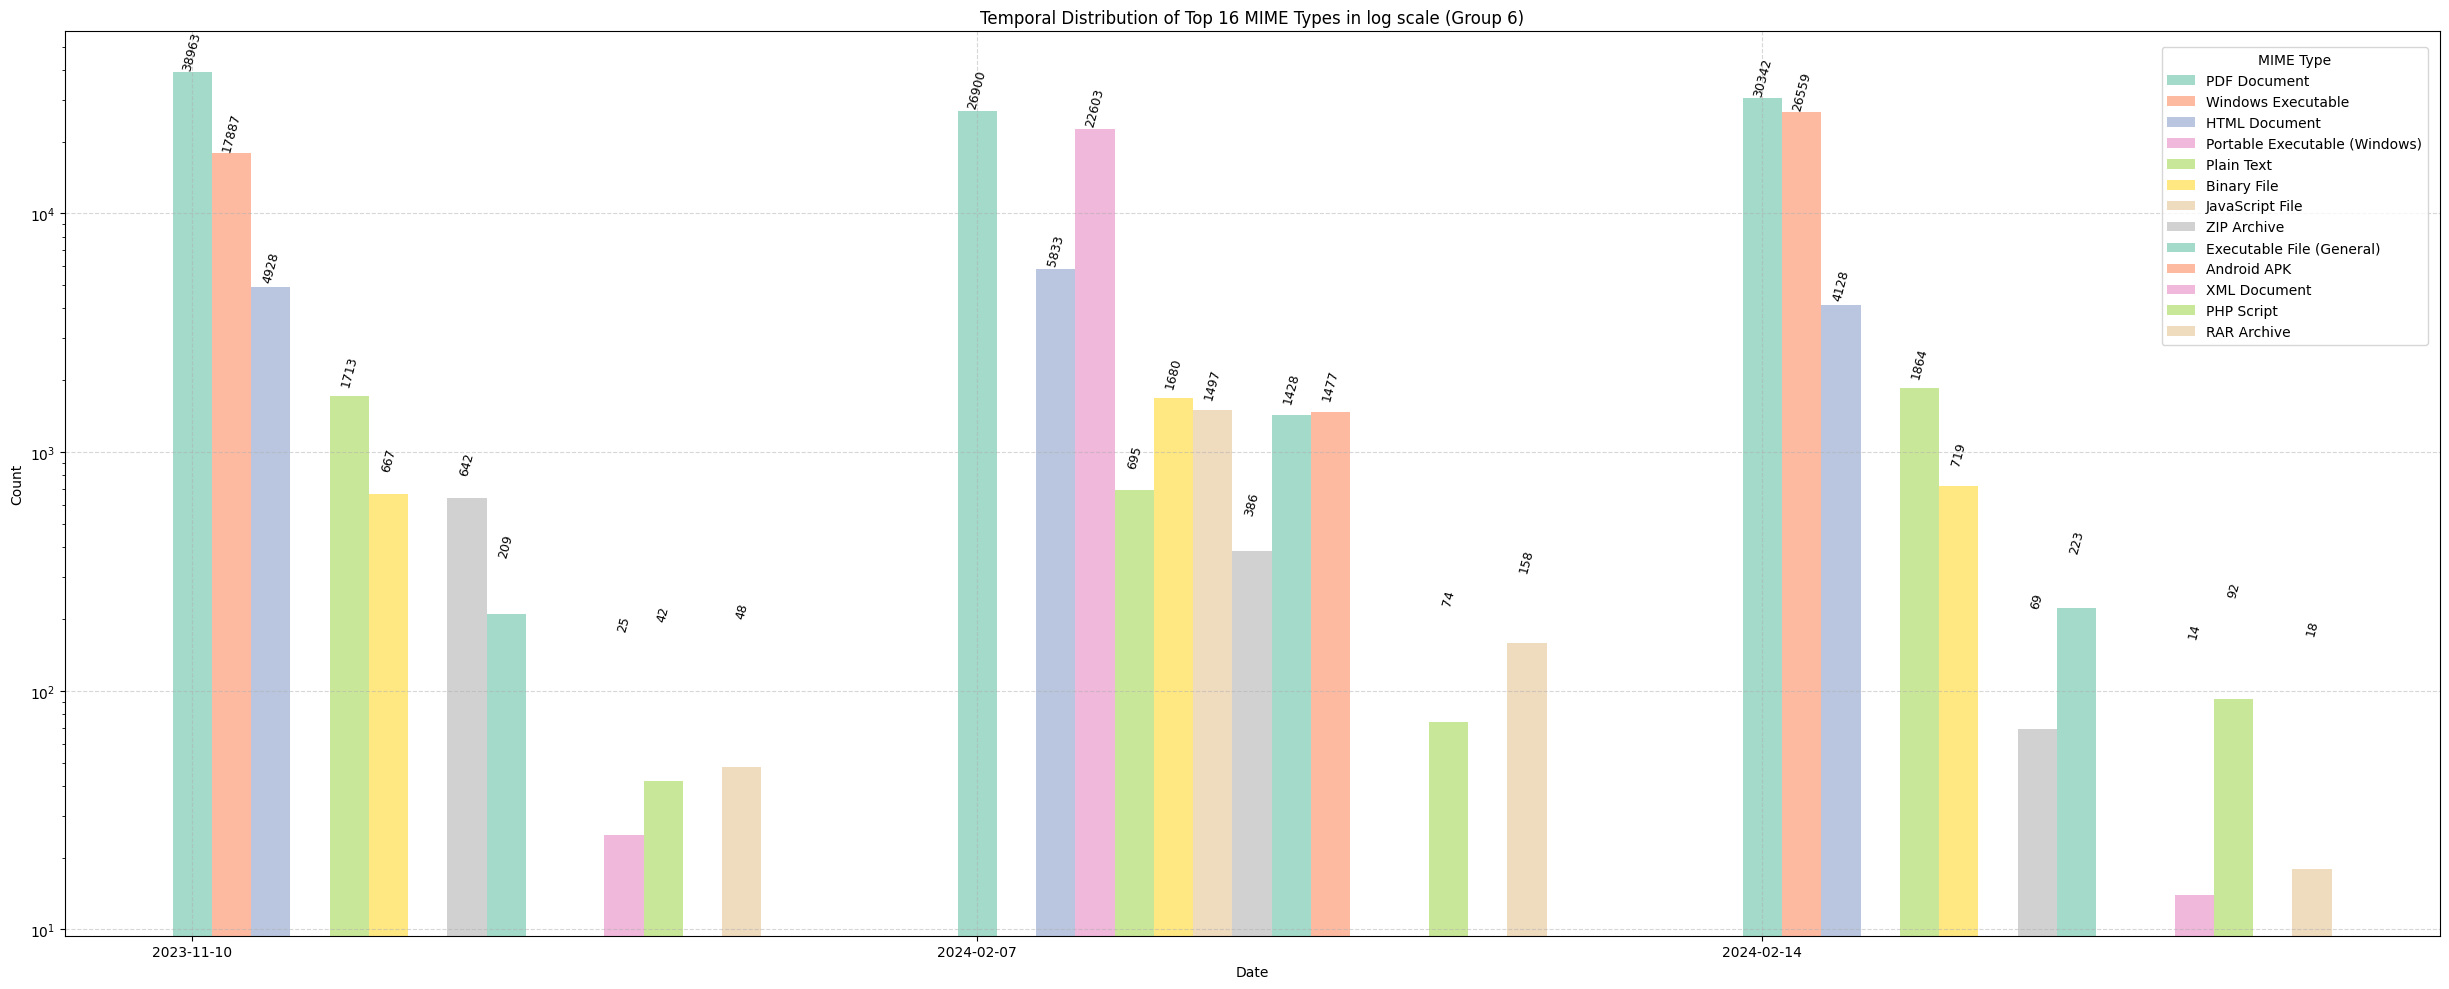

In [28]:

# Directory containing the CSV files
directory = './TypeCounts/'

# Dictionary to store data for temporal plots
temporal_data_16 = {}

# Function to read a CSV file and process it
def read_mime_counts(file_path):
    df = pd.read_csv(file_path)
    # Split column string into separate columns if necessary
    if 'Tipo MIME,Count,Arquivo' in df.columns:
        df[['MIME_type', 'Count', 'Arquivo']] = df['Tipo MIME,Count,Arquivo'].str.split(',', expand=True)
        df = df[['MIME_type', 'Count']]  # Retain only the needed columns
    
    # Convert 'Count' column to integer
    df['Count'] = df['Count'].astype(int)
    return df

# Iterate over all files in the directory
for filename in os.listdir(directory):
    if filename.startswith('mime_counts') and filename.endswith('.csv'):
        file_path = os.path.join(directory, filename)
        df = read_mime_counts(file_path)

        # Sort by count in descending order and get top 16
        df = df.sort_values(by='Count', ascending=False)
        top_16 = df.head(16)

        # Store data in dictionary for plotting
        for index, row in top_16.iterrows():
            mime_type = row['MIME_type']
            count = row['Count']
            if filename not in temporal_data_16:
                temporal_data_16[filename] = []
            temporal_data_16[filename].append((mime_type, count))

# Creating a mapping dictionary for renaming
mime_to_name_mapping = {
    'application/pdf': 'PDF Document',
    'application/x-dosexec': 'Windows Executable',
    'text/html': 'HTML Document',
    'application/vnd.microsoft.portable-executable': 'Portable Executable (Windows)',
    'text/plain': 'Plain Text',
    'application/octet-stream': 'Binary File',
    'application/javascript': 'JavaScript File',
    'application/zip': 'ZIP Archive',
    'application/x-executable': 'Executable File (General)',
    'application/vnd.android.package-archive': 'Android APK',
    'application/x-msdos-batch': 'Batch Script',
    'text/xml': 'XML Document',
    'text/x-php': 'PHP Script',
    'application/x-ms-shortcut': 'Windows Shortcut',
    'application/x-rar': 'RAR Archive'
}

# Define a fixed color palette for all MIME types
# This will ensure the same color order for each MIME type across all plots
colors = sns.color_palette("Set2", len(mime_to_name_mapping))  # Using Set2 palette from seaborn

# Create a mapping from MIME type to color
mime_type_to_color = {mime: colors[i] for i, mime in enumerate(mime_to_name_mapping.values())}

# Plotting grouped data
files = list(temporal_data_16.keys())
file_groups = [files[i:i + 3] for i in range(0, len(files), 3)]

# Iterate over each group of files and create a plot for each group
for i, file_group in enumerate(file_groups):
    temporal_data_group = {key: [] for key in mime_to_name_mapping.values()}
    
    for file in file_group:
        date = pd.to_datetime(virusshare_dates[file])
        mime_list = temporal_data_16[file]
        
        for mime_type, count in mime_list:
            if mime_type in mime_to_name_mapping:
                conventional_name = mime_to_name_mapping[mime_type]
                temporal_data_group[conventional_name].append((date, count))
    
    # Prepare figure for the bar graph
    plt.figure(figsize=(25, 10))
    bar_width = 0.05
    
    all_dates = set()
    for data in temporal_data_group.values():
        if data:
            dates, _ = zip(*data)
            all_dates.update(dates)
    
    all_dates = sorted(all_dates)
    date_to_index = {date: idx for idx, date in enumerate(all_dates)}
    
    for idx, (mime_type, data) in enumerate(temporal_data_group.items()):
        data = sorted(data, key=lambda x: x[0])
        if data:
            dates, counts = zip(*data)
            date_indices = [date_to_index[date] for date in dates]
            # Use the fixed color from mime_type_to_color
            bars = plt.bar([x + idx * bar_width for x in date_indices], counts, width=bar_width, 
                           label=mime_type, alpha=0.6, color=mime_type_to_color[mime_type])
            
            # Adding the count labels on top of the bars with modifications
            for bar in bars:
                yval = bar.get_height()
                xval = bar.get_x() + bar.get_width() / 2
                
                # Vary the height a bit to avoid overlap and tilt the number
                offset = 150  # Randomly adjust the offset to prevent overlap
                rotated_angle = 75  # Random angle for rotation to make numbers more readable
                
                # Use plt.text to add the number with tilting and different height positioning
                plt.text(xval, yval + offset, int(yval), ha='center', va='bottom', fontsize=9, rotation=rotated_angle)
                
                
    plt.xticks(range(len(all_dates)), [date.strftime('%Y-%m-%d') for date in all_dates])
    plt.title(f'Temporal Distribution of Top 16 MIME Types in log scale (Group {i + 1})')
    plt.xlabel('Date')
    plt.ylabel('Count')
    plt.yscale('log')
    plt.legend(title='MIME Type', bbox_to_anchor=(0.88, 0.99), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    
    plt.show()
